# Tanaos Topic Classification : Meta Features

## Imports

In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB,GaussianNB
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score, f1_score,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import gensim
import gensim.downloader as api
from gensim.models import KeyedVectors
import os
from scipy.sparse import hstack
from scipy.special import softmax
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

## Load Dataset

In this section, we load the training dataset and inspect its basic structure.
The goal is to understand:

- how many examples are available;
- which columns exist;
- how labels are stored;
- whether there are missing values;
- whether the dataset appears balanced across classes.

In [2]:
df = pd.read_csv("data/train_data.csv")

In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (10232, 2)

Columns:
['text', 'labels']

Data types:
text        str
labels    int64
dtype: object

Missing values:
text      0
labels    0
dtype: int64


In [4]:
df.head()

,text,labels
0,The rise of populist movements has reshaped gl...,0
1,A balanced diet rich in fruits and vegetables ...,1
2,Quantum cryptography is revolutionizing secure...,2
3,Streaming platforms have transformed how audie...,3
4,Crypto investors are diversifying portfolios a...,4


In [5]:
topics = ["politics","health","technology","entertainment","money_finance","relationships_dating","education_learning","work_careers","science","society_culture","gaming","lifestyle_hobbies","sports","automotive","other"]

### Label Mapping

The dataset stores class labels numerically, so we define a dictionary that maps each numeric label to its corresponding topic name.

In [6]:
topic_dict = dict(enumerate(topics))
print(topic_dict)

{0: 'politics', 1: 'health', 2: 'technology', 3: 'entertainment', 4: 'money_finance', 5: 'relationships_dating', 6: 'education_learning', 7: 'work_careers', 8: 'science', 9: 'society_culture', 10: 'gaming', 11: 'lifestyle_hobbies', 12: 'sports', 13: 'automotive', 14: 'other'}


In [7]:
print("Columns:", df.columns.tolist())
print("Unique labels:", sorted(df["labels"].unique()))
print("Number of classes:", df["labels"].nunique())

Columns: ['text', 'labels']
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
Number of classes: 15


### Load Embeddings

In [8]:
model_path = "model/word2vec-google-news-300.kv"

folder_name = os.path.dirname(model_path)
if folder_name:
    os.makedirs(folder_name, exist_ok=True)

if os.path.exists(model_path):
    print("Found saved model! Loading from disk...")
    wv = KeyedVectors.load(model_path)
    print("Model loaded successfully!")

else:
    print("Model not found locally. Downloading from Gensim (this may take a few minutes)...")
    wv = api.load('word2vec-google-news-300')

    print("Download complete! Saving to disk for next time...")
    wv.save(model_path)
    print("Model saved successfully!")

Found saved model! Loading from disk...
Model loaded successfully!


## Preprocessing Strategy

Before training any classifier, the text is normalized in order to reduce noise and make the feature extraction more consistent.

The preprocessing steps used here are:

- removal of non-alphabetic characters;
- conversion to lowercase;
- tokenization by whitespace splitting;
- stopword removal;
- stemming with PorterStemmer.

A small exception is made for negation-related words, since removing them may discard useful meaning.

## Cleanup and normalization


In [9]:
negations_to_keep = {
    "no", "nor", "not", "ain", "aren", "aren't", "couldn", "couldn't", "didn", "didn't",
    "doesn", "doesn't", "hadn", "hadn't", "hasn", "hasn't", "haven", "haven't", "isn",
    "isn't", "mightn", "mightn't", "mustn", "mustn't", "needn", "needn't", "shan",
    "shan't", "shouldn", "shouldn't", "wasn", "wasn't", "weren", "weren't", "won",
    "won't", "wouldn", "wouldn't"
}

In [10]:
corpus = []
ps = PorterStemmer()
sw = set(stopwords.words('english'))
sw = sw-negations_to_keep
for i in range(0, df['text'].size):
    # get review and remove non alpha chars
    review = re.sub('[^a-zA-Z]', ' ', df['text'][i])
    # to lower-case
    review = review.lower()
    # split into tokens, apply stemming and remove stop words
    review = ' '.join([ps.stem(w) for w in review.split() if w not in sw])
    corpus.append(review)

print("Number of processed documents:", len(corpus))
print("\nExample original text:")
print(df['text'].iloc[0])

print("\nExample processed text:")
print(corpus[0])

Number of processed documents: 10232

Example original text:
The rise of populist movements has reshaped global political landscapes.

Example processed text:
rise populist movement reshap global polit landscap


In [11]:
df["processed_text"] = corpus
df.head()

,text,labels,processed_text
0,The rise of populist movements has reshaped gl...,0,rise populist movement reshap global polit lan...
1,A balanced diet rich in fruits and vegetables ...,1,balanc diet rich fruit veget support long term...
2,Quantum cryptography is revolutionizing secure...,2,quantum cryptographi revolution secur commun m...
3,Streaming platforms have transformed how audie...,3,stream platform transform audienc consum tv co...
4,Crypto investors are diversifying portfolios a...,4,crypto investor diversifi portfolio amid marke...


In [12]:
unstemmed_corpus = []
for i in range(0, df['text'].size):
    review = re.sub('[^a-zA-Z]', ' ', df['text'][i])
    review = review.lower()
    review = ' '.join([w for w in review.split() if w not in sw])
    unstemmed_corpus.append(review)

df["unstemmed_text"] = unstemmed_corpus

In [13]:
df.head()

,text,labels,processed_text,unstemmed_text
0,The rise of populist movements has reshaped gl...,0,rise populist movement reshap global polit lan...,rise populist movements reshaped global politi...
1,A balanced diet rich in fruits and vegetables ...,1,balanc diet rich fruit veget support long term...,balanced diet rich fruits vegetables supports ...
2,Quantum cryptography is revolutionizing secure...,2,quantum cryptographi revolution secur commun m...,quantum cryptography revolutionizing secure co...
3,Streaming platforms have transformed how audie...,3,stream platform transform audienc consum tv co...,streaming platforms transformed audiences cons...
4,Crypto investors are diversifying portfolios a...,4,crypto investor diversifi portfolio amid marke...,crypto investors diversifying portfolios amid ...


In [14]:
df["text_length_chars"] = df["text"].astype(str).apply(len)
df["text_length_words"] = df["text"].astype(str).apply(lambda x: len(x.split()))
df['avg_word_length'] = np.where(df['text_length_words'] > 0,
                                 df['text_length_chars'] / df['text_length_words'],
                                 0)
print(df[["text_length_chars", "text_length_words","avg_word_length"]].describe())

       text_length_chars  text_length_words  avg_word_length
count       10232.000000       10232.000000     10232.000000
mean          117.031274          16.935301         7.022594
std            33.527611           5.239986         0.909038
min            27.000000           3.000000         4.318182
25%            93.000000          13.000000         6.380952
50%           113.000000          16.000000         6.955534
75%           136.000000          20.000000         7.600000
max           374.000000          57.000000        11.500000


## Pre-processing and Feature Representation

### Bag of Words

In this first baseline, we use a sparse Bag-of-Words representation with `CountVectorizer`.

This means each document is represented by a vector of token counts, where:

- each feature corresponds to a vocabulary term;
- the value indicates how many times that term appears in the document.

This is a simple and standard baseline for text classification.

In [15]:
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(corpus)

print("Feature matrix shape:", X_bow.shape)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

Feature matrix shape: (10232, 5673)
Vocabulary size: 5673


In [16]:
feature_names = vectorizer.get_feature_names_out()

print("First 100 features:")
print(feature_names[:100])

First 100 features:
['aaa' 'abandon' 'abel' 'abil' 'abl' 'abnorm' 'abort' 'abroad' 'abruptli'
 'absolut' 'abstract' 'abu' 'abuzz' 'acacia' 'academ' 'academi' 'academia'
 'acceler' 'accept' 'access' 'accessori' 'accid' 'acclaim' 'accommod'
 'accomplish' 'accord' 'account' 'accountablil' 'accredit' 'accumul'
 'accur' 'accuraci' 'accus' 'acestop' 'achiev' 'acidifi' 'acknowledg'
 'acl' 'acoust' 'acquir' 'acquisit' 'across' 'acsm' 'act' 'action' 'activ'
 'activist' 'actor' 'actress' 'actual' 'ad' 'adapt' 'add' 'addict' 'addit'
 'address' 'adjust' 'administr' 'admiss' 'adob' 'adolesc' 'adopt'
 'adrenalin' 'adriana' 'adult' 'adulthood' 'advanc' 'advantag' 'advent'
 'adventur' 'advers' 'advertis' 'advic' 'advis' 'advisor' 'advisori'
 'advoc' 'advocaci' 'aerial' 'aerob' 'aerodynam' 'aerospac' 'aesthet'
 'affair' 'affect' 'affirm' 'afford' 'afloat' 'africa' 'african'
 'afrobeat' 'aftermath' 'age' 'agenc' 'agenda' 'agent' 'aggreg' 'aggress'
 'ago' 'agoni']


In [17]:
y = df['labels']

print("X_bow shape:", X_bow.shape)
print("y shape:", y.shape)


X_bow shape: (10232, 5673)
y shape: (10232,)


In [18]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df["processed_text"])

print("TF-IDF feature matrix shape:", X_tfidf.shape)
print("TF-IDF vocabulary size:", len(tfidf_vectorizer.get_feature_names_out()))

TF-IDF feature matrix shape: (10232, 5673)
TF-IDF vocabulary size: 5673


### 1-hot vectors

In [19]:
vectorizer = CountVectorizer(binary=True)
X_onehot = vectorizer.fit_transform(corpus)

print("Feature matrix shape:", X_onehot.shape)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

Feature matrix shape: (10232, 5673)
Vocabulary size: 5673


### N-Grams

In [20]:
vectorizer = CountVectorizer(ngram_range=(1, 2))

X_grams = vectorizer.fit_transform(corpus)

print("Feature matrix shape:", X_grams.shape)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

Feature matrix shape: (10232, 54607)
Vocabulary size: 54607


### Embeddings

In [21]:
def text_to_mean_vector(embeddings, text):
    tokens = text.split()

    valid_vectors = []
    for token in tokens:
        try:
            valid_vectors.append(embeddings.get_vector(token))
        except KeyError:
            pass

    if not valid_vectors:

        return np.zeros(embeddings.vector_size)

    return np.mean(valid_vectors, axis=0)

In [22]:
def text_to_max_vector(embeddings, text):
    tokens = text.split()

    valid_vectors = []
    for token in tokens:
        try:
            valid_vectors.append(embeddings.get_vector(token))
        except KeyError:
            pass

    if not valid_vectors:
        return np.zeros(embeddings.vector_size)

    return np.max(valid_vectors, axis=0)

In [23]:
embeddings_mean_corpus = []
for c in unstemmed_corpus:
    embeddings_mean_corpus.append(text_to_mean_vector(wv, c))

X_embedding_mean = np.array(embeddings_mean_corpus)

print(X_embedding_mean.shape, y.shape)

(10232, 300) (10232,)


In [24]:
embeddings_max_corpus = []
for c in unstemmed_corpus:
    embeddings_max_corpus.append(text_to_max_vector(wv, c))

X_embedding_max = np.array(embeddings_max_corpus)

print(X_embedding_max.shape, y.shape)

(10232, 300) (10232,)


## Split Dataset

The dataset is split into training and test sets.

A stratified split is used so that the label distribution remains approximately the same in both sets.  
This is important in multiclass classification, especially if some classes are less frequent than others.

In [25]:
meta_features = df[['text_length_chars', 'text_length_words', 'avg_word_length']].values

In [26]:
X_bow_combined = hstack((X_bow, meta_features))

X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(
    X_bow_combined, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(X_train_bow.shape, y_train_bow.shape)
print(X_test_bow.shape, y_test_bow.shape)

print("\nLabel distribution in the training set:")
print(y_train_bow.value_counts().sort_index())

print("\nLabel distribution in the test set:")
print(y_test_bow.value_counts().sort_index())

(8185, 5676) (8185,)
(2047, 5676) (2047,)

Label distribution in the training set:
labels
0     468
1     926
2     818
3     666
4     630
5     403
6     544
7     510
8     706
9     511
10    511
11    606
12    380
13    399
14    107
Name: count, dtype: int64

Label distribution in the test set:
labels
0     117
1     231
2     205
3     167
4     158
5     100
6     136
7     127
8     177
9     127
10    128
11    152
12     95
13    100
14     27
Name: count, dtype: int64


To ensure a fair comparison with the previous baseline, we apply the same train/test split strategy to the TF-IDF representation.


In [27]:
X_train_tfidf, X_test_tfidf, meta_train, meta_test, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf, meta_features, y, test_size=0.20, random_state=42, stratify=y
)

print(X_train_tfidf.shape, y_train_tfidf.shape)
print(X_test_tfidf.shape, y_test_tfidf.shape)

(8185, 5673) (8185,)
(2047, 5673) (2047,)


In [28]:
X_onehot_combined = hstack((X_onehot, meta_features))

X_train_onehot, X_test_onehot, y_train_onehot, y_test_onehot = train_test_split(
    X_onehot_combined, y, test_size=0.20, random_state=42, stratify=y
)

print(X_train_onehot.shape, y_train_onehot.shape)
print(X_test_onehot.shape, y_test_onehot.shape)

(8185, 5676) (8185,)
(2047, 5676) (2047,)


In [29]:
X_grams_combined = hstack((X_grams, meta_features))

X_train_grams, X_test_grams, y_train_grams, y_test_grams = train_test_split(
    X_grams_combined, y, test_size=0.20, random_state=42, stratify=y
)

print(X_train_grams.shape, y_train_grams.shape)
print(X_test_grams.shape, y_test_grams.shape)

(8185, 54610) (8185,)
(2047, 54610) (2047,)


In [30]:
X_emb_mean_combined = np.hstack((X_embedding_mean, meta_features))

X_train_embeddings_mean, X_test_embeddings_mean, y_train_embeddings_mean, y_test_embeddings_mean = train_test_split(
    X_emb_mean_combined, y, test_size=0.20, random_state=42, stratify=y
)

print(X_train_embeddings_mean.shape, y_train_embeddings_mean.shape)
print(X_test_embeddings_mean.shape, y_test_embeddings_mean.shape)

(8185, 303) (8185,)
(2047, 303) (2047,)


In [31]:
X_emb_max_combined = np.hstack((X_embedding_max, meta_features))

X_train_embeddings_max, X_test_embeddings_max, y_train_embeddings_max, y_test_embeddings_max = train_test_split(
    X_emb_max_combined, y, test_size=0.20, random_state=42, stratify=y
)
print(X_train_embeddings_max.shape, y_train_embeddings_max.shape)
print(X_test_embeddings_max.shape, y_test_embeddings_max.shape)

(8185, 303) (8185,)
(2047, 303) (2047,)


In [32]:
# BoW (MaxAbsScaler keeps zeros intact and values positive)
scaler_bow = MaxAbsScaler()
X_train_bow_final = scaler_bow.fit_transform(X_train_bow)
X_test_bow_final = scaler_bow.transform(X_test_bow)

# N-grams
scaler_grams = MaxAbsScaler()
X_train_grams_final = scaler_grams.fit_transform(X_train_grams)
X_test_grams_final = scaler_grams.transform(X_test_grams)

# One-hot
scaler_onehot = MaxAbsScaler()
X_train_onehot_final = scaler_onehot.fit_transform(X_train_onehot)
X_test_onehot_final = scaler_onehot.transform(X_test_onehot)

# TF-IDF Meta Features
scaler_meta_minmax = MinMaxScaler()
meta_train_scaled_mm = scaler_meta_minmax.fit_transform(meta_train)
meta_test_scaled_mm = scaler_meta_minmax.transform(meta_test)

X_train_tfidf_final = hstack((X_train_tfidf, meta_train_scaled_mm))
X_test_tfidf_final = hstack((X_test_tfidf, meta_test_scaled_mm))

# Mean Embeddings (StandardScaler for the win!)
scaler_emb_mean = StandardScaler()
X_train_embeddings_mean_final = scaler_emb_mean.fit_transform(X_train_embeddings_mean)
X_test_embeddings_mean_final = scaler_emb_mean.transform(X_test_embeddings_mean)

# Max Embeddings
scaler_emb_max = StandardScaler()
X_train_embeddings_max_final = scaler_emb_max.fit_transform(X_train_embeddings_max)
X_test_embeddings_max_final = scaler_emb_max.transform(X_test_embeddings_max)

## Model Training and Evaluation

In [33]:
def evaluate_models(X_train, X_test, y_train, y_test, target_names=None, is_embeddings=False):
    """
    Trains multiple models, evaluates their performance, and returns:
    1. A metrics DataFrame (overall scores including ROC-AUC)
    2. A dictionary of confusion matrices
    3. A dictionary of classification reports
    """

    if is_embeddings:
        nb_name = 'Gaussian Naive Bayes'
        nb_model = GaussianNB()
    else:
        nb_name = 'Multinomial Naive Bayes'
        nb_model = MultinomialNB(alpha=1.0)

    models = {
        nb_name: nb_model,

        'Logistic Regression (L2)': LogisticRegression(
            max_iter=5000,
            class_weight='balanced',
            random_state=42
        ),

        'Logistic Regression (L1)': LogisticRegression(
            l1_ratio=1,
            solver='saga',
            max_iter=5000,
            tol=0.01,
            class_weight='balanced',
            random_state=42
        ),

        'Linear SVM (L2)': LinearSVC(
            max_iter=5000,
            class_weight='balanced',
            random_state=42
        ),

        'Linear SVM (L1)': LinearSVC(
            penalty='l1',
            dual=False,
            max_iter=5000,
            class_weight='balanced',
            random_state=42
        ),

        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            max_depth=50,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        ),

        'XGBoost': XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            n_jobs=-1,
            random_state=42
        )
    }

    metrics_data = []
    cm_dict = {}
    cr_dict = {}

    for model_name, model in models.items():

        # Fit the model
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)
        else:
            y_scores = model.decision_function(X_test)
            y_prob = softmax(y_scores, axis=1)

        y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)

        # Calculate metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        f1_m = f1_score(y_test, y_pred, average='macro', zero_division=0)
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

        metrics_data.append({
            'Model': model_name,
            'Accuracy': acc,
            'Precision (weighted)': prec,
            'Recall (weighted)': rec,
            'F1 (weighted)': f1_w,
            'F1 (macro)': f1_m,
            'ROC-AUC (weighted)': roc_auc
        })

        # Store confusion matrix
        cm_dict[model_name] = confusion_matrix(y_test, y_pred)

        # Store classification report
        cr_dict[model_name] = classification_report(
            y_test,
            y_pred,
            target_names=target_names,
            output_dict=True,
            zero_division=0
        )

    metrics_df = pd.DataFrame(metrics_data).set_index('Model')

    return metrics_df, cm_dict, cr_dict



In [34]:
def display_model_evaluations(confusion_matrices, class_reports, class_names):
    """5000
    Iterates through model results to neatly display classification reports
    and plot confusion matrix heatmaps.

    Args:
        confusion_matrices (dict): Dictionary mapping model names to confusion matrices.
        class_reports (dict): Dictionary mapping model names to classification reports (as dicts).
        class_names (list): List of string labels for the classes (e.g., your topics).
    """
    for model_name in confusion_matrices.keys():
        print(f"\n{'='*50}")
        print(f"MODEL: {model_name}")
        print(f"{'='*50}\n")

        print("--- Classification Report ---")
        report_df = pd.DataFrame(class_reports[model_name]).transpose()
        display(report_df.round(4))
        print("\n")

        print("--- Confusion Matrix ---")
        cm = confusion_matrices[model_name]

        plt.figure(figsize=(8, 6))

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)

        plt.ylabel('Actual Class')
        plt.xlabel('Predicted Class')
        plt.title(f'{model_name} - Confusion Matrix')
        plt.xticks(rotation=45, ha='right')

        plt.tight_layout()
        plt.show()

### BOW

As a first baseline model, we use **Multinomial Naive Bayes**.

This classifier is commonly used in text classification because it works well with count-based sparse representations such as Bag-of-Words.  
Its purpose here is to provide a simple reference point against which stronger models can later be compared.

In [35]:
metrics_df_bow, confusion_matrices_bow, class_reports_bow = evaluate_models(
    X_train_bow_final, X_test_bow_final, y_train_bow, y_test_bow, target_names=topics
)

/home/joao-proenca/Desktop/MIA 1º Ano/2º Semestre/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [36]:
display(metrics_df_bow.sort_values(by='F1 (macro)', ascending=False))

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (weighted)
Model,,,,,,
Logistic Regression (L1),0.887152,0.889086,0.887152,0.887710,0.860234,0.990946
Logistic Regression (L2),0.888129,0.890148,0.888129,0.888695,0.858869,0.992632
Linear SVM (L1),0.889106,0.885939,0.889106,0.886836,0.856180,0.986855
XGBoost,0.878359,0.877355,0.878359,0.876538,0.853581,0.990314
Linear SVM (L2),0.884221,0.882905,0.884221,0.883122,0.853490,0.986121
Random Forest,0.855887,0.863692,0.855887,0.857947,0.830168,0.986429
Multinomial Naive Bayes,0.867123,0.865029,0.867123,0.861998,0.820230,0.990032



MODEL: Multinomial Naive Bayes

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8710,0.9231,0.8963,117.0000
health,0.8120,0.9351,0.8692,231.0000
technology,0.8080,0.8829,0.8438,205.0000
entertainment,0.9383,0.9102,0.9240,167.0000
money_finance,0.9597,0.9051,0.9316,158.0000
relationships_dating,0.9250,0.7400,0.8222,100.0000
education_learning,0.8929,0.9191,0.9058,136.0000
work_careers,0.8000,0.8189,0.8093,127.0000
science,0.8387,0.8814,0.8595,177.0000
society_culture,0.7373,0.6850,0.7102,127.0000




--- Confusion Matrix ---


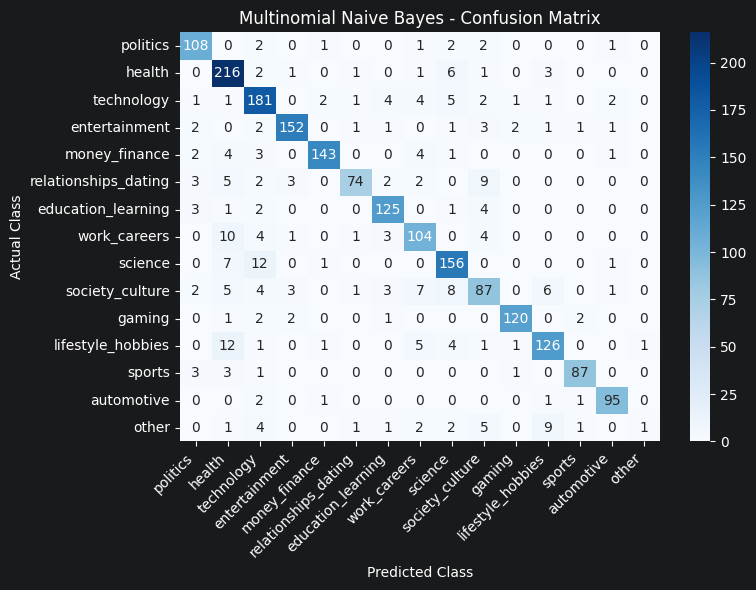


MODEL: Logistic Regression (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8793,0.8718,0.8755,117.0000
health,0.9021,0.9177,0.9099,231.0000
technology,0.8571,0.8780,0.8675,205.0000
entertainment,0.9325,0.9102,0.9212,167.0000
money_finance,0.9662,0.9051,0.9346,158.0000
relationships_dating,0.9000,0.9000,0.9000,100.0000
education_learning,0.9220,0.9559,0.9386,136.0000
work_careers,0.8582,0.9055,0.8812,127.0000
science,0.8556,0.9040,0.8791,177.0000
society_culture,0.8087,0.7323,0.7686,127.0000




--- Confusion Matrix ---


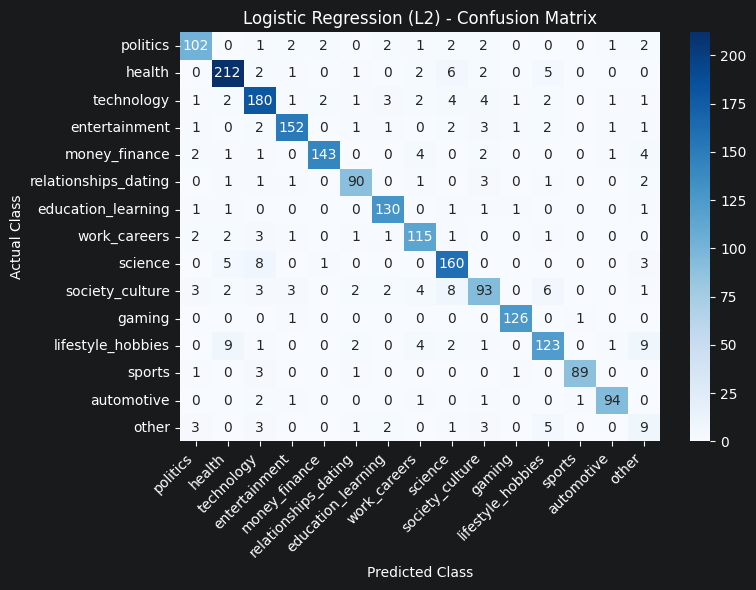


MODEL: Logistic Regression (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9712,0.8632,0.9140,117.0000
health,0.8970,0.9048,0.9009,231.0000
technology,0.8517,0.8683,0.8599,205.0000
entertainment,0.9255,0.8922,0.9085,167.0000
money_finance,0.9554,0.9494,0.9524,158.0000
relationships_dating,0.8990,0.8900,0.8945,100.0000
education_learning,0.9034,0.9632,0.9324,136.0000
work_careers,0.8582,0.9055,0.8812,127.0000
science,0.8764,0.8814,0.8789,177.0000
society_culture,0.7857,0.7795,0.7826,127.0000




--- Confusion Matrix ---


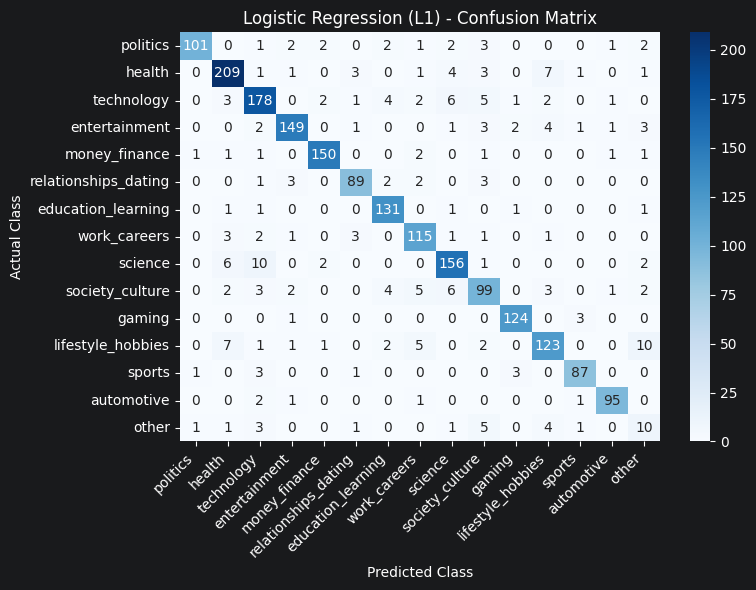


MODEL: Linear SVM (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8306,0.8803,0.8548,117.0000
health,0.8724,0.9177,0.8945,231.0000
technology,0.8647,0.8732,0.8689,205.0000
entertainment,0.9091,0.8982,0.9036,167.0000
money_finance,0.9600,0.9114,0.9351,158.0000
relationships_dating,0.8990,0.8900,0.8945,100.0000
education_learning,0.9220,0.9559,0.9386,136.0000
work_careers,0.8976,0.8976,0.8976,127.0000
science,0.8361,0.8644,0.8500,177.0000
society_culture,0.8070,0.7244,0.7635,127.0000




--- Confusion Matrix ---


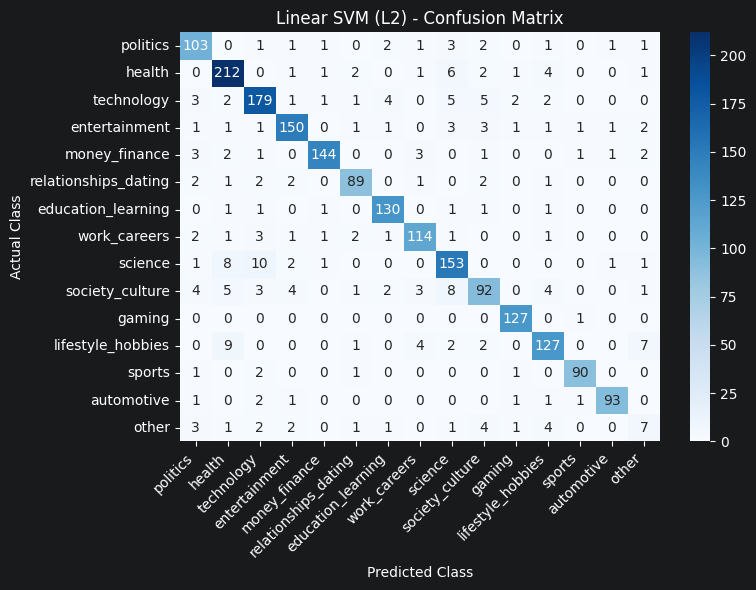


MODEL: Linear SVM (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8957,0.8803,0.8879,117.0000
health,0.8623,0.9221,0.8912,231.0000
technology,0.8689,0.8732,0.8710,205.0000
entertainment,0.9141,0.8922,0.9030,167.0000
money_finance,0.9551,0.9430,0.9490,158.0000
relationships_dating,0.8878,0.8700,0.8788,100.0000
education_learning,0.9225,0.9632,0.9424,136.0000
work_careers,0.8855,0.9134,0.8992,127.0000
science,0.8525,0.8814,0.8667,177.0000
society_culture,0.8053,0.7165,0.7583,127.0000




--- Confusion Matrix ---


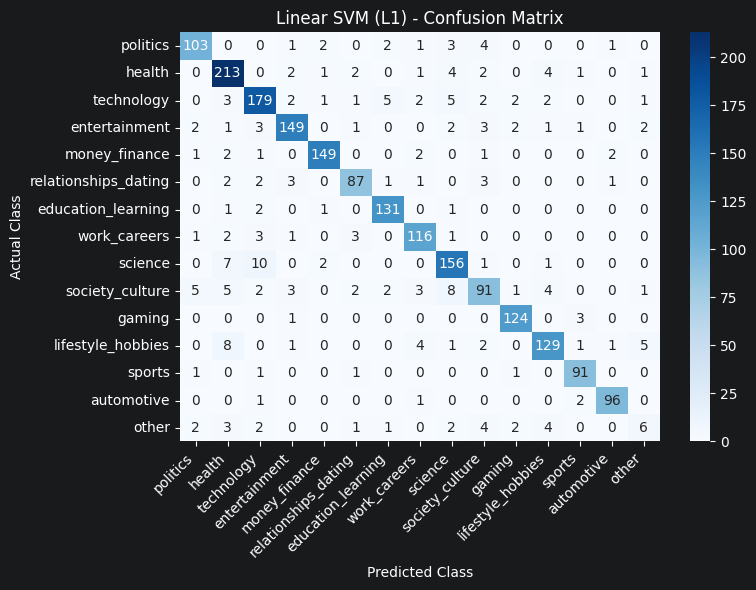


MODEL: Random Forest

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8783,0.8632,0.8707,117.0000
health,0.8578,0.8615,0.8596,231.0000
technology,0.8608,0.8146,0.8371,205.0000
entertainment,0.9226,0.8563,0.8882,167.0000
money_finance,0.9136,0.9367,0.9250,158.0000
relationships_dating,0.8936,0.8400,0.8660,100.0000
education_learning,0.8571,0.9265,0.8905,136.0000
work_careers,0.8099,0.9055,0.8550,127.0000
science,0.7887,0.8644,0.8248,177.0000
society_culture,0.8235,0.6614,0.7336,127.0000




--- Confusion Matrix ---


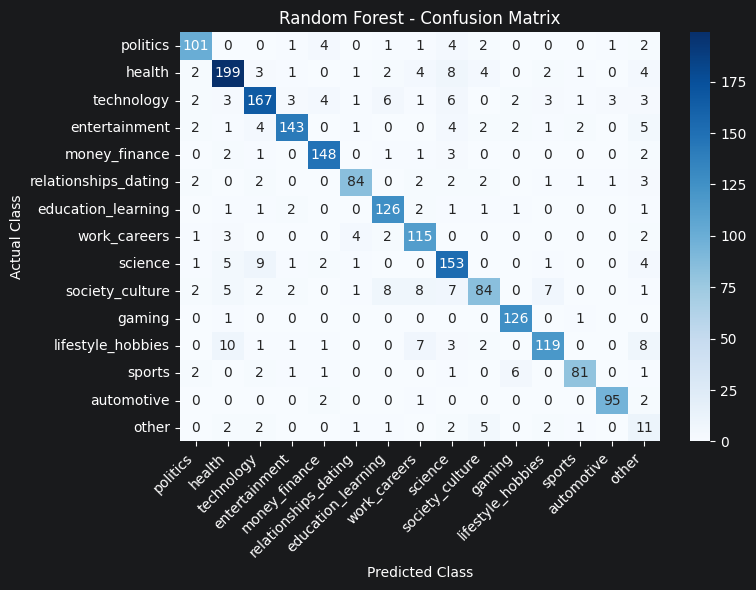


MODEL: XGBoost

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9423,0.8376,0.8869,117.0000
health,0.8594,0.9264,0.8917,231.0000
technology,0.8000,0.8585,0.8282,205.0000
entertainment,0.9114,0.8623,0.8862,167.0000
money_finance,0.9202,0.9494,0.9346,158.0000
relationships_dating,0.9167,0.8800,0.8980,100.0000
education_learning,0.8851,0.9632,0.9225,136.0000
work_careers,0.8507,0.8976,0.8736,127.0000
science,0.8531,0.8531,0.8531,177.0000
society_culture,0.7863,0.7244,0.7541,127.0000




--- Confusion Matrix ---


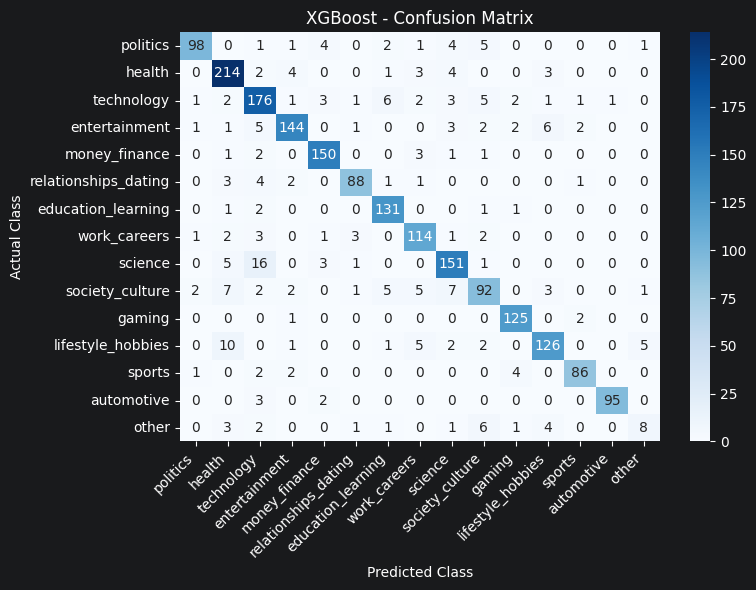

In [37]:
display_model_evaluations(confusion_matrices_bow, class_reports_bow, topics)

### TF-IDF

Logistic Regression is one of the strongest traditional baselines for multiclass text classification.

It often performs better than Naive Bayes because it learns direct decision boundaries between classes instead of relying on stronger independence assumptions.

In [38]:
metrics_df_tfidf, confusion_matrices_tfidf, class_reports_tfidf = evaluate_models(
    X_train_tfidf_final, X_test_tfidf_final, y_train_tfidf, y_test_tfidf, target_names=topics
)

/home/joao-proenca/Desktop/MIA 1º Ano/2º Semestre/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [39]:
display(metrics_df_tfidf.sort_values(by='F1 (macro)', ascending=False))

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (weighted)
Model,,,,,,
Linear SVM (L1),0.900342,0.899409,0.900342,0.899215,0.875183,0.990173
Linear SVM (L2),0.898876,0.897270,0.898876,0.897429,0.869966,0.990517
Logistic Regression (L2),0.891060,0.895602,0.891060,0.892651,0.866527,0.993248
XGBoost,0.868100,0.868431,0.868100,0.866372,0.846685,0.988654
Logistic Regression (L1),0.863703,0.869520,0.863703,0.865690,0.842939,0.988593
Random Forest,0.848559,0.858731,0.848559,0.851467,0.822919,0.985112
Multinomial Naive Bayes,0.850024,0.851012,0.850024,0.844572,0.800437,0.989414



MODEL: Multinomial Naive Bayes

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8879,0.8120,0.8482,117.00
health,0.7194,0.9654,0.8244,231.00
technology,0.7441,0.9220,0.8235,205.00
entertainment,0.9217,0.9162,0.9189,167.00
money_finance,0.9726,0.8987,0.9342,158.00
relationships_dating,0.9848,0.6500,0.7831,100.00
education_learning,0.8986,0.9118,0.9051,136.00
work_careers,0.8908,0.8346,0.8618,127.00
science,0.7990,0.8757,0.8356,177.00
society_culture,0.7431,0.6378,0.6864,127.00




--- Confusion Matrix ---


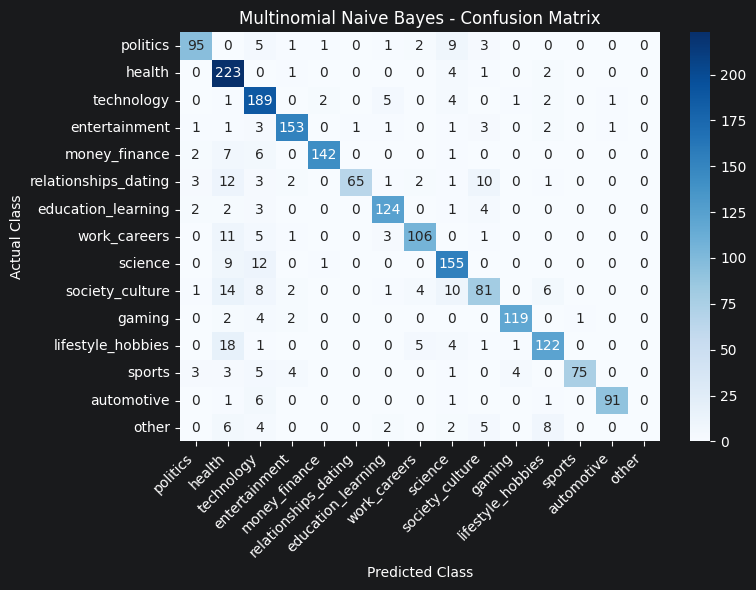


MODEL: Logistic Regression (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9130,0.8974,0.9052,117.0000
health,0.9170,0.9091,0.9130,231.0000
technology,0.8708,0.8878,0.8792,205.0000
entertainment,0.9198,0.8922,0.9058,167.0000
money_finance,0.9800,0.9304,0.9545,158.0000
relationships_dating,0.9082,0.8900,0.8990,100.0000
education_learning,0.9085,0.9485,0.9281,136.0000
work_careers,0.8370,0.8898,0.8626,127.0000
science,0.8533,0.8870,0.8698,177.0000
society_culture,0.8067,0.7559,0.7805,127.0000




--- Confusion Matrix ---


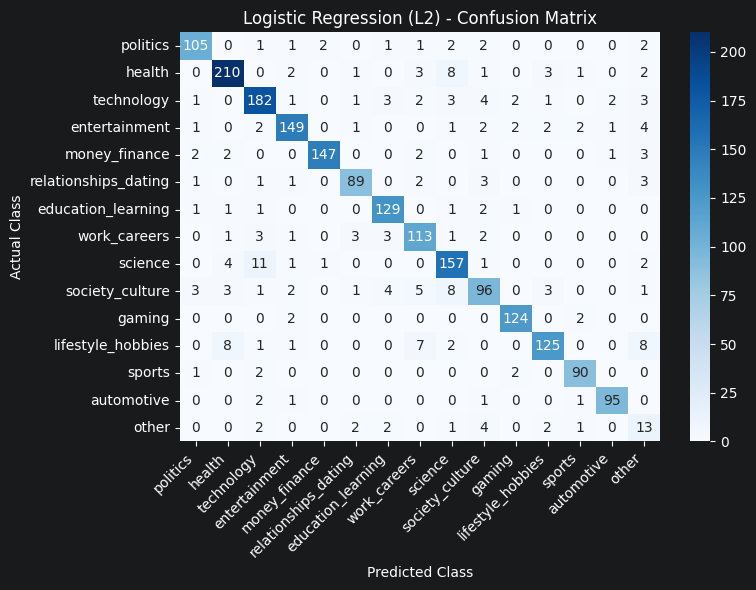


MODEL: Logistic Regression (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9245,0.8376,0.8789,117.0000
health,0.8821,0.8745,0.8783,231.0000
technology,0.8492,0.8244,0.8366,205.0000
entertainment,0.9119,0.8683,0.8896,167.0000
money_finance,0.9481,0.9241,0.9359,158.0000
relationships_dating,0.8544,0.8800,0.8670,100.0000
education_learning,0.8936,0.9265,0.9097,136.0000
work_careers,0.7902,0.8898,0.8370,127.0000
science,0.8547,0.8305,0.8424,177.0000
society_culture,0.7480,0.7244,0.7360,127.0000




--- Confusion Matrix ---


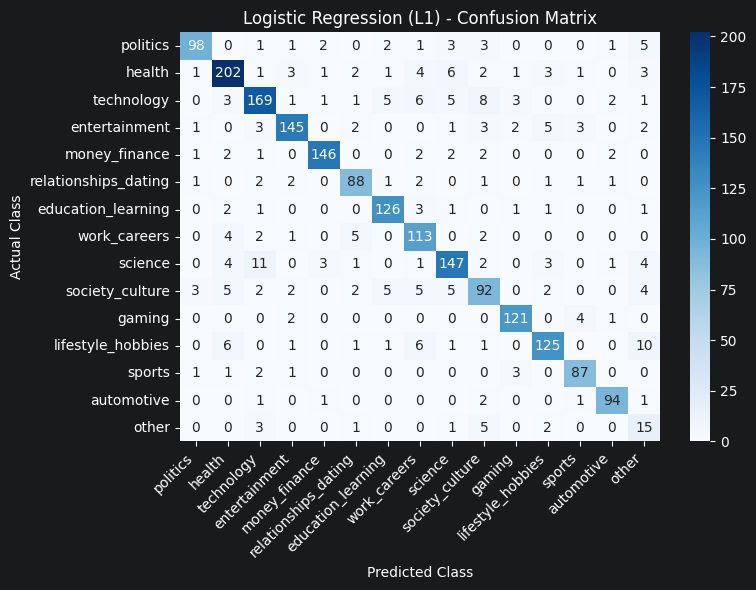


MODEL: Linear SVM (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8974,0.8974,0.8974,117.0000
health,0.8884,0.9307,0.9091,231.0000
technology,0.8578,0.8829,0.8702,205.0000
entertainment,0.9325,0.9102,0.9212,167.0000
money_finance,0.9618,0.9557,0.9587,158.0000
relationships_dating,0.9381,0.9100,0.9239,100.0000
education_learning,0.9155,0.9559,0.9353,136.0000
work_careers,0.8741,0.9291,0.9008,127.0000
science,0.8564,0.8757,0.8659,177.0000
society_culture,0.8468,0.7402,0.7899,127.0000




--- Confusion Matrix ---


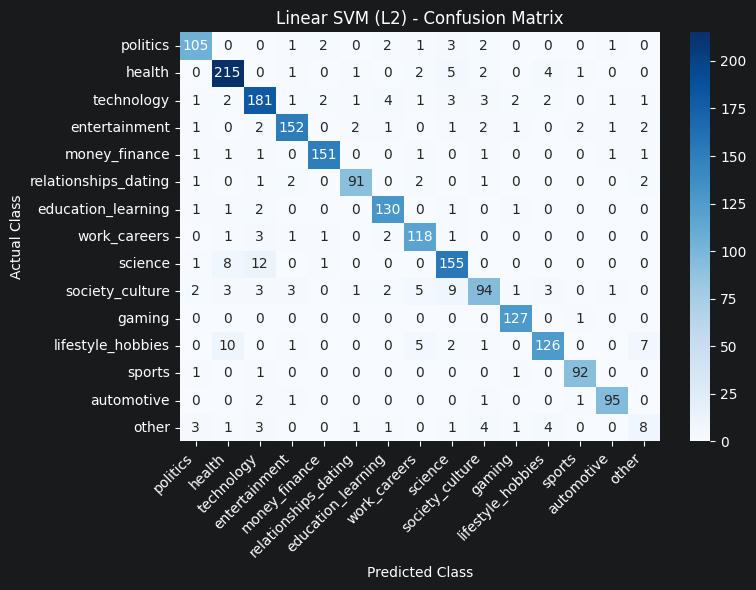


MODEL: Linear SVM (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9444,0.8718,0.9067,117.0000
health,0.8917,0.9264,0.9087,231.0000
technology,0.8873,0.8829,0.8851,205.0000
entertainment,0.9162,0.9162,0.9162,167.0000
money_finance,0.9739,0.9430,0.9582,158.0000
relationships_dating,0.9091,0.9000,0.9045,100.0000
education_learning,0.9116,0.9853,0.9470,136.0000
work_careers,0.8551,0.9291,0.8906,127.0000
science,0.8533,0.8870,0.8698,177.0000
society_culture,0.8276,0.7559,0.7901,127.0000




--- Confusion Matrix ---


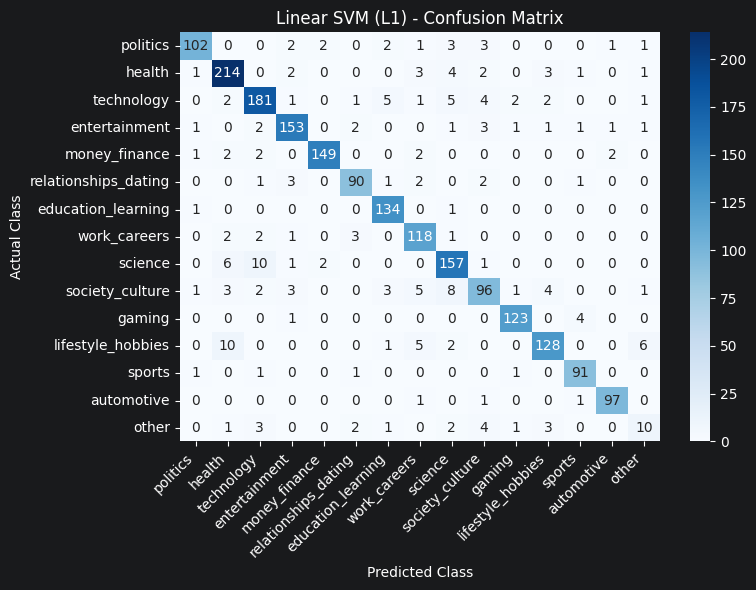


MODEL: Random Forest

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8761,0.8462,0.8609,117.0000
health,0.8333,0.8658,0.8493,231.0000
technology,0.8602,0.7805,0.8184,205.0000
entertainment,0.9114,0.8623,0.8862,167.0000
money_finance,0.9182,0.9241,0.9211,158.0000
relationships_dating,0.8936,0.8400,0.8660,100.0000
education_learning,0.8533,0.9412,0.8951,136.0000
work_careers,0.8188,0.8898,0.8528,127.0000
science,0.7744,0.8531,0.8118,177.0000
society_culture,0.8247,0.6299,0.7143,127.0000




--- Confusion Matrix ---


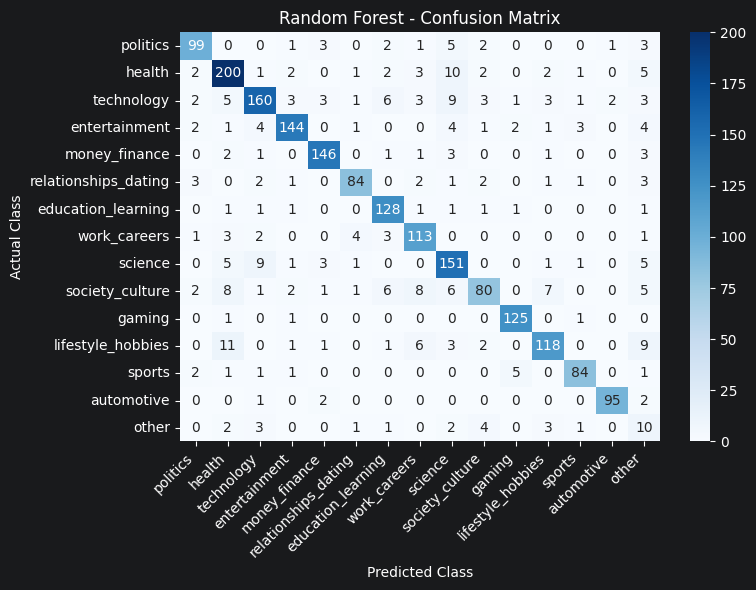


MODEL: XGBoost

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9346,0.8547,0.8929,117.0000
health,0.8300,0.9091,0.8678,231.0000
technology,0.7565,0.8488,0.8000,205.0000
entertainment,0.9211,0.8383,0.8777,167.0000
money_finance,0.9188,0.9304,0.9245,158.0000
relationships_dating,0.9263,0.8800,0.9026,100.0000
education_learning,0.8904,0.9559,0.9220,136.0000
work_careers,0.8357,0.9213,0.8764,127.0000
science,0.8315,0.8362,0.8338,177.0000
society_culture,0.7838,0.6850,0.7311,127.0000




--- Confusion Matrix ---


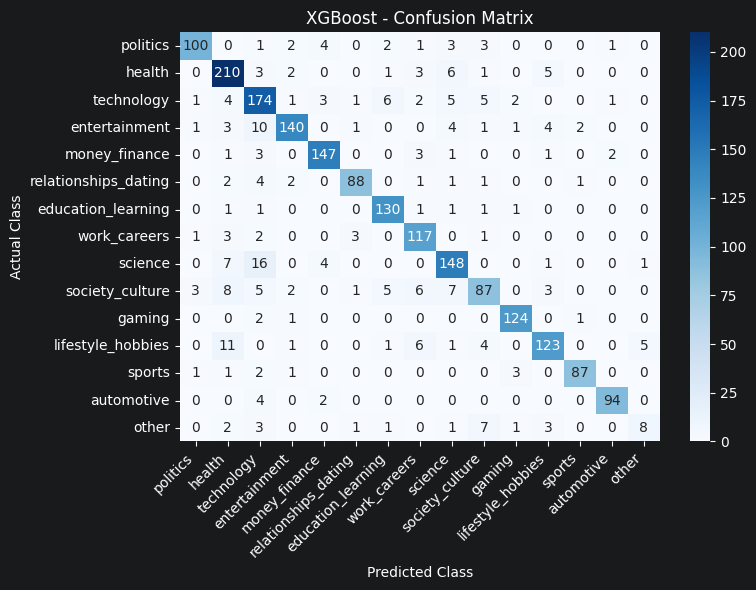

In [40]:
display_model_evaluations(confusion_matrices_tfidf, class_reports_tfidf, topics)

### 1-hot vectors

In [41]:
metrics_df_onehot, confusion_matrices_onehot, class_reports_onehot = evaluate_models(
    X_train_onehot_final, X_test_onehot_final, y_train_onehot, y_test_onehot, target_names=topics
)

In [42]:
display(metrics_df_bow.sort_values(by='F1 (macro)', ascending=False))

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (weighted)
Model,,,,,,
Logistic Regression (L1),0.887152,0.889086,0.887152,0.887710,0.860234,0.990946
Logistic Regression (L2),0.888129,0.890148,0.888129,0.888695,0.858869,0.992632
Linear SVM (L1),0.889106,0.885939,0.889106,0.886836,0.856180,0.986855
XGBoost,0.878359,0.877355,0.878359,0.876538,0.853581,0.990314
Linear SVM (L2),0.884221,0.882905,0.884221,0.883122,0.853490,0.986121
Random Forest,0.855887,0.863692,0.855887,0.857947,0.830168,0.986429
Multinomial Naive Bayes,0.867123,0.865029,0.867123,0.861998,0.820230,0.990032



MODEL: Multinomial Naive Bayes

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8983,0.9060,0.9021,117.0000
health,0.8504,0.9351,0.8907,231.0000
technology,0.8326,0.8976,0.8638,205.0000
entertainment,0.9441,0.9102,0.9268,167.0000
money_finance,0.9728,0.9051,0.9377,158.0000
relationships_dating,0.9195,0.8000,0.8556,100.0000
education_learning,0.8873,0.9265,0.9065,136.0000
work_careers,0.8195,0.8583,0.8385,127.0000
science,0.8587,0.8927,0.8753,177.0000
society_culture,0.7623,0.7323,0.7470,127.0000




--- Confusion Matrix ---


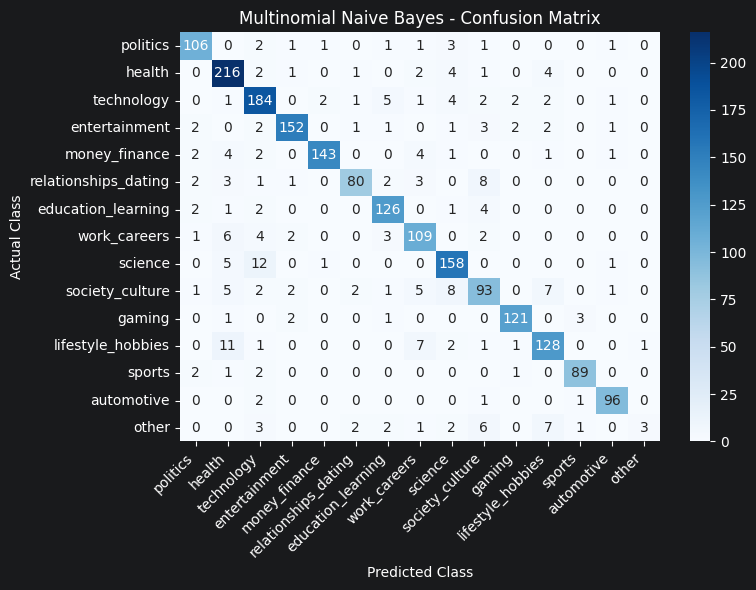


MODEL: Logistic Regression (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9035,0.8803,0.8918,117.000
health,0.8950,0.9221,0.9083,231.000
technology,0.8565,0.9024,0.8789,205.000
entertainment,0.9146,0.8982,0.9063,167.000
money_finance,0.9733,0.9241,0.9481,158.000
relationships_dating,0.8750,0.9100,0.8922,100.000
education_learning,0.9225,0.9632,0.9424,136.000
work_careers,0.9040,0.8898,0.8968,127.000
science,0.8441,0.8870,0.8650,177.000
society_culture,0.8205,0.7559,0.7869,127.000




--- Confusion Matrix ---


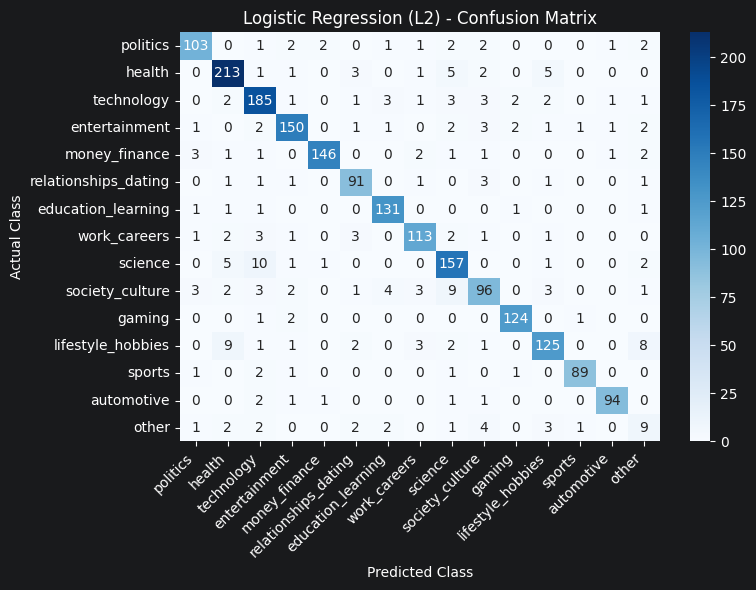


MODEL: Logistic Regression (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9714,0.8718,0.9189,117.0000
health,0.9060,0.9177,0.9118,231.0000
technology,0.8394,0.8927,0.8652,205.0000
entertainment,0.9080,0.8862,0.8970,167.0000
money_finance,0.9673,0.9367,0.9518,158.0000
relationships_dating,0.8654,0.9000,0.8824,100.0000
education_learning,0.9155,0.9559,0.9353,136.0000
work_careers,0.8582,0.9055,0.8812,127.0000
science,0.8857,0.8757,0.8807,177.0000
society_culture,0.8065,0.7874,0.7968,127.0000




--- Confusion Matrix ---


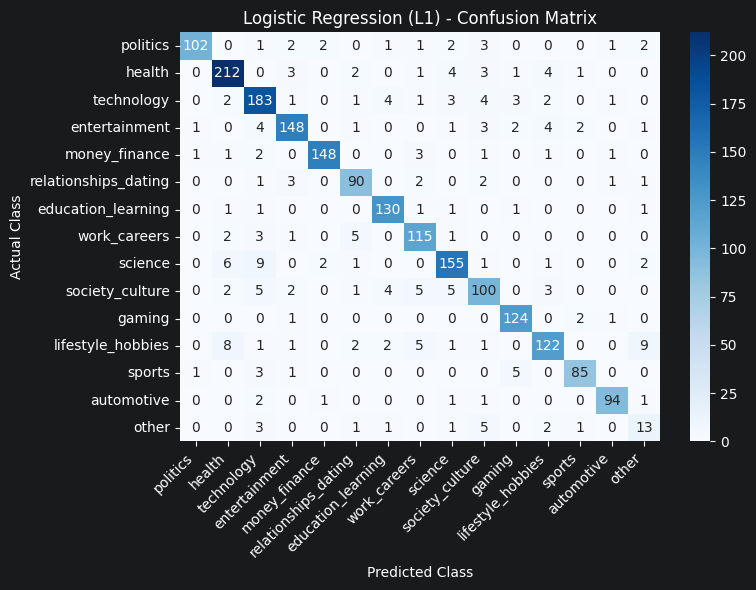


MODEL: Linear SVM (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8870,0.8718,0.8793,117.0000
health,0.8683,0.9134,0.8903,231.0000
technology,0.8626,0.8878,0.8750,205.0000
entertainment,0.9136,0.8862,0.8997,167.0000
money_finance,0.9597,0.9051,0.9316,158.0000
relationships_dating,0.8750,0.9100,0.8922,100.0000
education_learning,0.9091,0.9559,0.9319,136.0000
work_careers,0.8819,0.8819,0.8819,127.0000
science,0.8361,0.8644,0.8500,177.0000
society_culture,0.7876,0.7008,0.7417,127.0000




--- Confusion Matrix ---


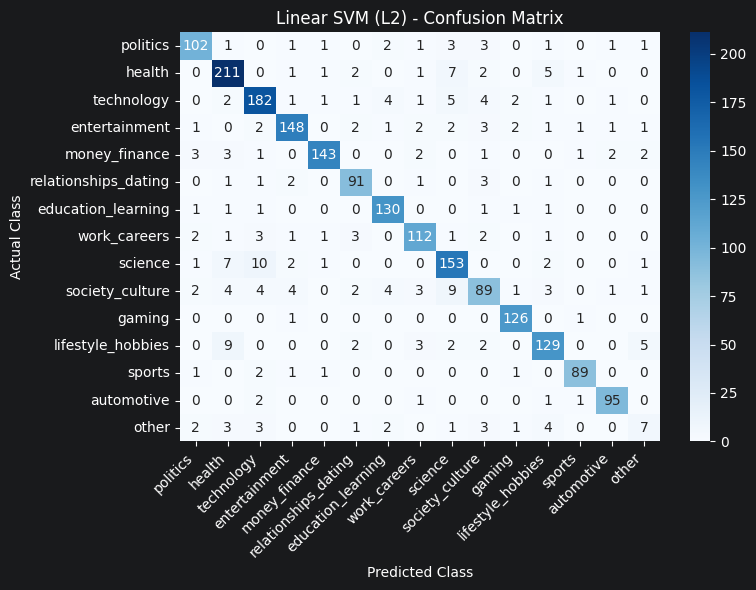


MODEL: Linear SVM (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9204,0.8889,0.9043,117.0000
health,0.8669,0.9307,0.8977,231.0000
technology,0.8702,0.8829,0.8765,205.0000
entertainment,0.9136,0.8862,0.8997,167.0000
money_finance,0.9740,0.9494,0.9615,158.0000
relationships_dating,0.8980,0.8800,0.8889,100.0000
education_learning,0.9161,0.9632,0.9391,136.0000
work_careers,0.8769,0.8976,0.8872,127.0000
science,0.8525,0.8814,0.8667,177.0000
society_culture,0.8053,0.7165,0.7583,127.0000




--- Confusion Matrix ---


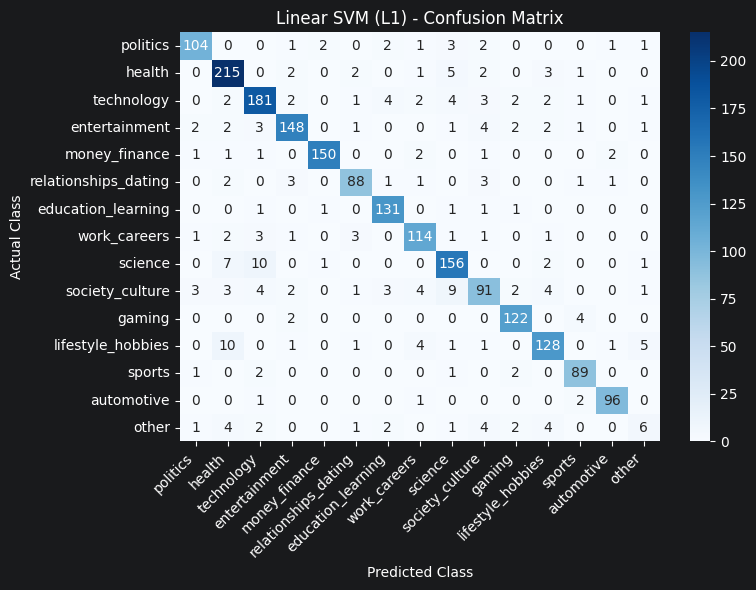


MODEL: Random Forest

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8860,0.8632,0.8745,117.0000
health,0.8578,0.8615,0.8596,231.0000
technology,0.8513,0.8098,0.8300,205.0000
entertainment,0.9231,0.8623,0.8916,167.0000
money_finance,0.9193,0.9367,0.9279,158.0000
relationships_dating,0.8830,0.8300,0.8557,100.0000
education_learning,0.8716,0.9485,0.9085,136.0000
work_careers,0.8309,0.8898,0.8593,127.0000
science,0.7789,0.8757,0.8245,177.0000
society_culture,0.8000,0.6929,0.7426,127.0000




--- Confusion Matrix ---


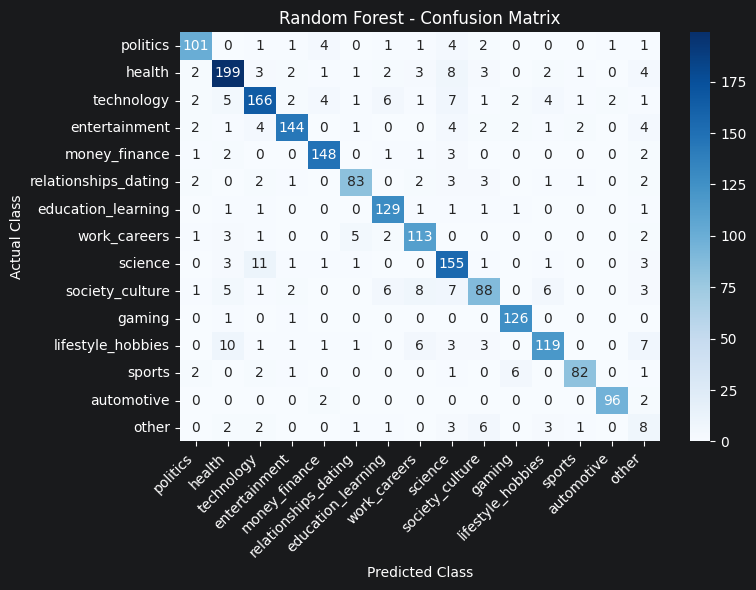


MODEL: XGBoost

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9423,0.8376,0.8869,117.0000
health,0.8465,0.9307,0.8866,231.0000
technology,0.7919,0.8537,0.8216,205.0000
entertainment,0.9231,0.8623,0.8916,167.0000
money_finance,0.9207,0.9557,0.9379,158.0000
relationships_dating,0.9271,0.8900,0.9082,100.0000
education_learning,0.8792,0.9632,0.9193,136.0000
work_careers,0.8496,0.8898,0.8692,127.0000
science,0.8514,0.8418,0.8466,177.0000
society_culture,0.7949,0.7323,0.7623,127.0000




--- Confusion Matrix ---


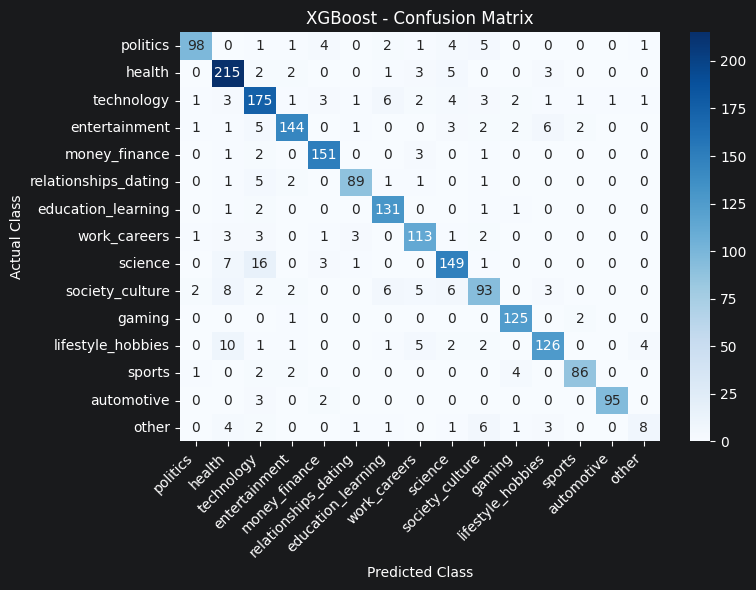

In [43]:
display_model_evaluations(confusion_matrices_onehot, class_reports_onehot, topics)

### N-Grams

In [44]:
metrics_df_grams, confusion_matrices_grams, class_reports_grams= evaluate_models(
    X_train_grams_final, X_test_grams_final, y_train_grams, y_test_grams, target_names=topics
)

In [45]:
display(metrics_df_grams.sort_values(by='F1 (macro)', ascending=False))

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (weighted)
Model,,,,,,
Logistic Regression (L2),0.896434,0.895128,0.896434,0.895207,0.867157,0.993536
Logistic Regression (L1),0.890083,0.889979,0.890083,0.889767,0.866255,0.992058
Linear SVM (L2),0.897899,0.895067,0.897899,0.895098,0.863967,0.989330
Linear SVM (L1),0.888617,0.886309,0.888617,0.886818,0.861536,0.987442
XGBoost,0.880313,0.879764,0.880313,0.878657,0.856059,0.990065
Random Forest,0.866146,0.865950,0.866146,0.864762,0.842950,0.986122
Multinomial Naive Bayes,0.877870,0.876226,0.877870,0.872726,0.830806,0.988392



MODEL: Multinomial Naive Bayes

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8560,0.9145,0.8843,117.0000
health,0.8302,0.9524,0.8871,231.0000
technology,0.7974,0.9024,0.8467,205.0000
entertainment,0.9226,0.9281,0.9254,167.0000
money_finance,0.9730,0.9114,0.9412,158.0000
relationships_dating,0.9506,0.7700,0.8508,100.0000
education_learning,0.9058,0.9191,0.9124,136.0000
work_careers,0.8421,0.8819,0.8615,127.0000
science,0.8470,0.8757,0.8611,177.0000
society_culture,0.7857,0.6929,0.7364,127.0000




--- Confusion Matrix ---


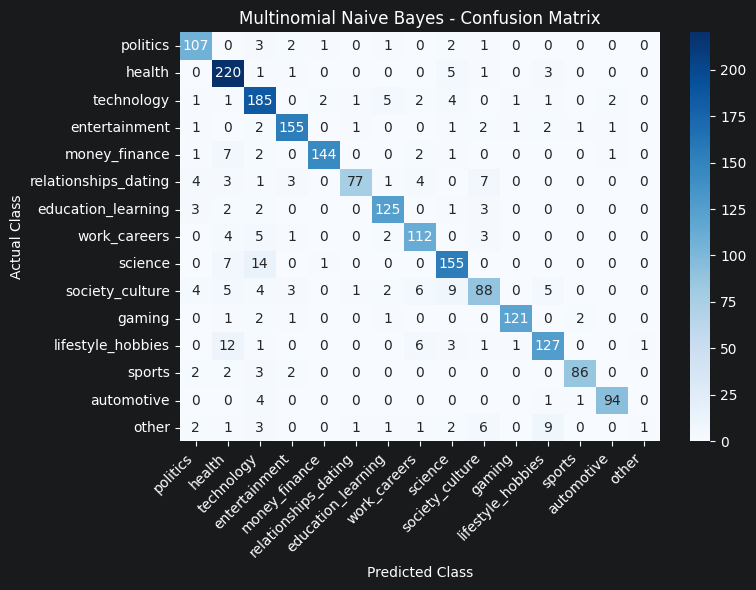


MODEL: Logistic Regression (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8966,0.8889,0.8927,117.0000
health,0.9060,0.9177,0.9118,231.0000
technology,0.8133,0.8927,0.8512,205.0000
entertainment,0.9277,0.9222,0.9249,167.0000
money_finance,0.9669,0.9241,0.9450,158.0000
relationships_dating,0.9100,0.9100,0.9100,100.0000
education_learning,0.9353,0.9559,0.9455,136.0000
work_careers,0.8760,0.8898,0.8828,127.0000
science,0.8649,0.9040,0.8840,177.0000
society_culture,0.8049,0.7795,0.7920,127.0000




--- Confusion Matrix ---


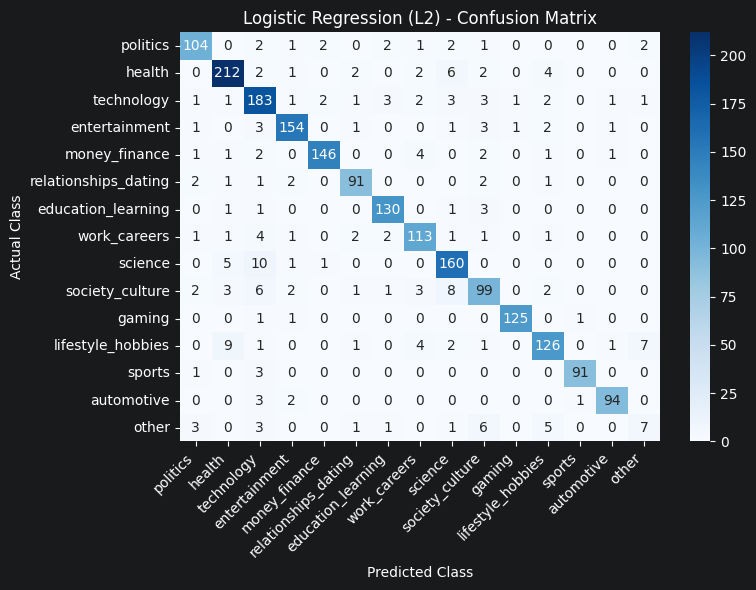


MODEL: Logistic Regression (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9189,0.8718,0.8947,117.0000
health,0.8979,0.9134,0.9056,231.0000
technology,0.8357,0.8683,0.8517,205.0000
entertainment,0.9202,0.8982,0.9091,167.0000
money_finance,0.9545,0.9304,0.9423,158.0000
relationships_dating,0.8725,0.8900,0.8812,100.0000
education_learning,0.9103,0.9706,0.9395,136.0000
work_careers,0.8855,0.9134,0.8992,127.0000
science,0.8771,0.8870,0.8820,177.0000
society_culture,0.8017,0.7638,0.7823,127.0000




--- Confusion Matrix ---


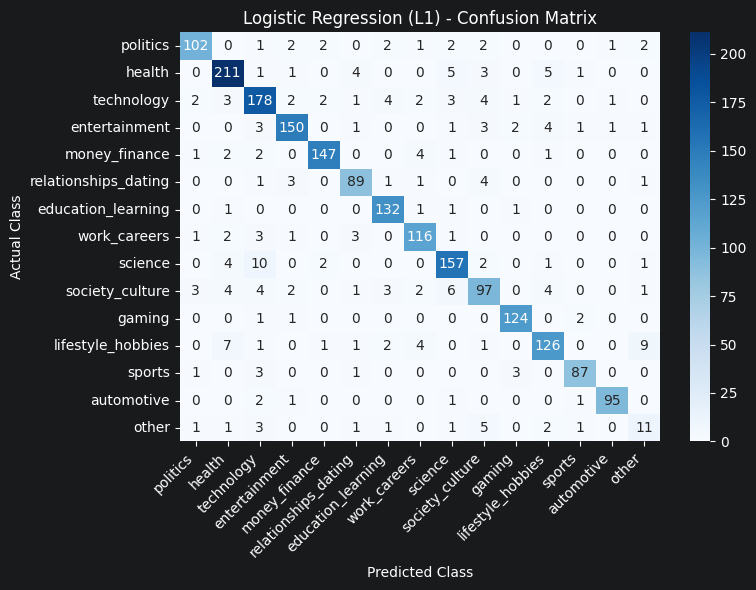


MODEL: Linear SVM (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8889,0.8889,0.8889,117.0000
health,0.8908,0.9177,0.9041,231.0000
technology,0.8430,0.9171,0.8785,205.0000
entertainment,0.9281,0.9281,0.9281,167.0000
money_finance,0.9669,0.9241,0.9450,158.0000
relationships_dating,0.9100,0.9100,0.9100,100.0000
education_learning,0.9357,0.9632,0.9493,136.0000
work_careers,0.8788,0.9134,0.8958,127.0000
science,0.8486,0.8870,0.8674,177.0000
society_culture,0.8087,0.7323,0.7686,127.0000




--- Confusion Matrix ---


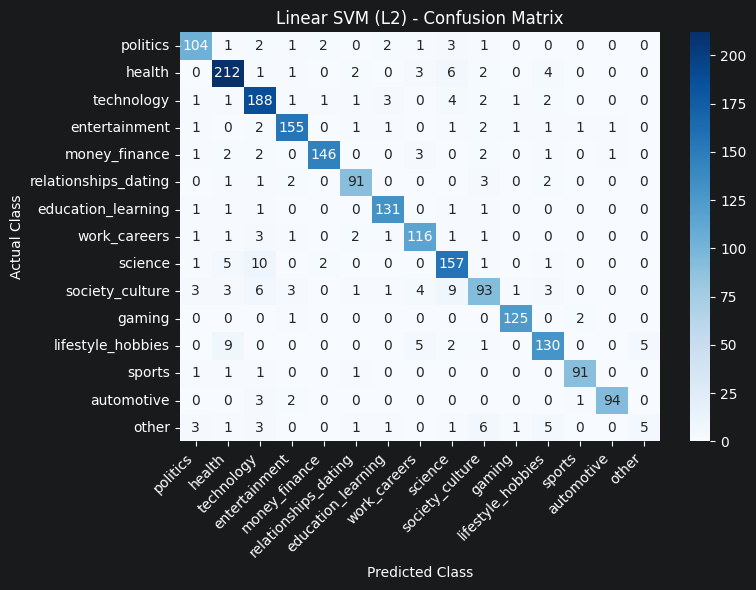


MODEL: Linear SVM (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8839,0.8462,0.8646,117.0000
health,0.8903,0.9134,0.9017,231.0000
technology,0.8451,0.8780,0.8612,205.0000
entertainment,0.8982,0.8982,0.8982,167.0000
money_finance,0.9427,0.9367,0.9397,158.0000
relationships_dating,0.9000,0.9000,0.9000,100.0000
education_learning,0.9281,0.9485,0.9382,136.0000
work_careers,0.8519,0.9055,0.8779,127.0000
science,0.8603,0.8701,0.8652,177.0000
society_culture,0.7966,0.7402,0.7673,127.0000




--- Confusion Matrix ---


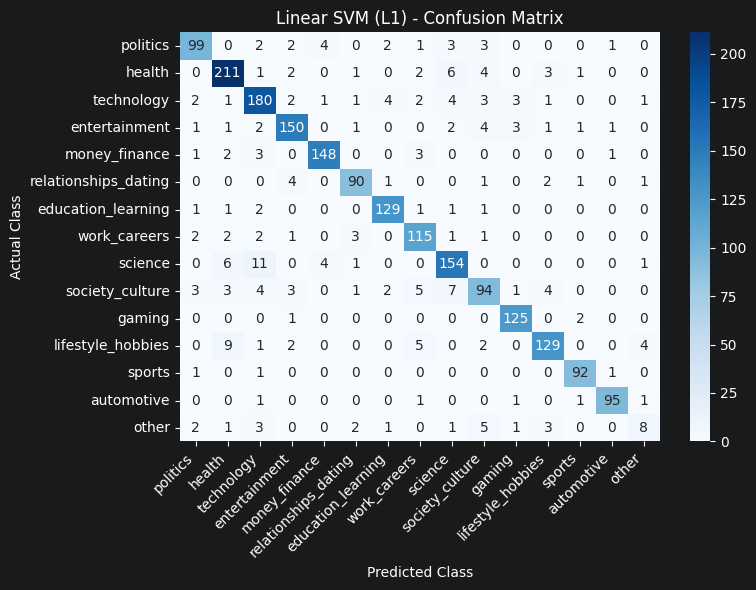


MODEL: Random Forest

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8803,0.8803,0.8803,117.0000
health,0.8690,0.8615,0.8652,231.0000
technology,0.8615,0.8195,0.8400,205.0000
entertainment,0.9119,0.8683,0.8896,167.0000
money_finance,0.9193,0.9367,0.9279,158.0000
relationships_dating,0.9043,0.8500,0.8763,100.0000
education_learning,0.8497,0.9559,0.8997,136.0000
work_careers,0.8261,0.8976,0.8604,127.0000
science,0.7828,0.8757,0.8267,177.0000
society_culture,0.8077,0.6614,0.7273,127.0000




--- Confusion Matrix ---


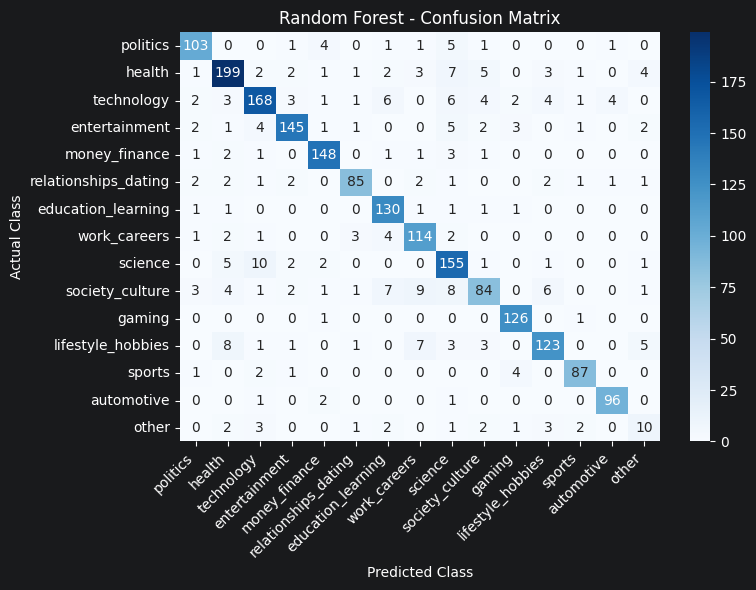


MODEL: XGBoost

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9423,0.8376,0.8869,117.0000
health,0.8465,0.9307,0.8866,231.0000
technology,0.8000,0.8585,0.8282,205.0000
entertainment,0.9177,0.8683,0.8923,167.0000
money_finance,0.9264,0.9557,0.9408,158.0000
relationships_dating,0.9263,0.8800,0.9026,100.0000
education_learning,0.8851,0.9632,0.9225,136.0000
work_careers,0.8571,0.8976,0.8769,127.0000
science,0.8563,0.8418,0.8490,177.0000
society_culture,0.7983,0.7480,0.7724,127.0000




--- Confusion Matrix ---


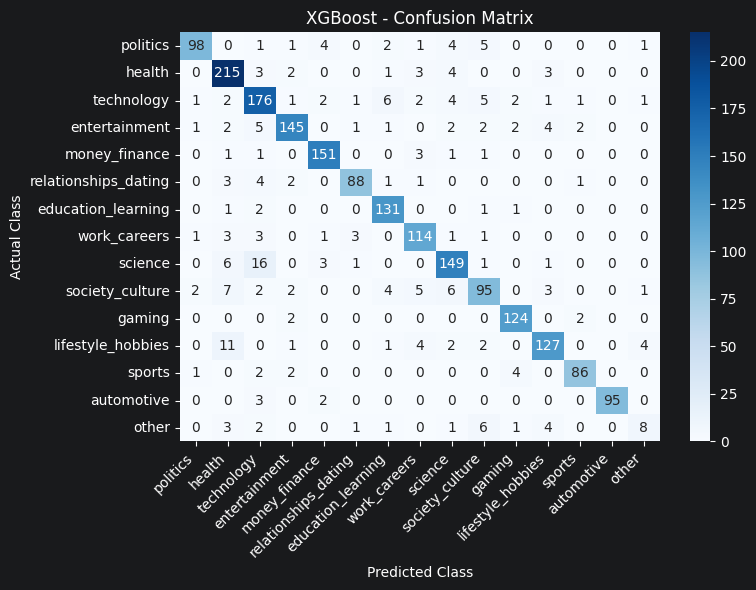

In [46]:
display_model_evaluations(confusion_matrices_grams, class_reports_grams, topics)

### Embeddings Mean

In [47]:
metrics_df_embeddings_mean, confusion_matrices_embeddings_mean, class_reports_embeddings_mean = evaluate_models(
    X_train_embeddings_mean_final, X_test_embeddings_mean_final, y_train_embeddings_mean, y_test_embeddings_mean, target_names=topics,is_embeddings=True
)

/home/joao-proenca/Desktop/MIA 1º Ano/2º Semestre/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [48]:
display(metrics_df_embeddings_mean.sort_values(by='F1 (macro)', ascending=False))

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (weighted)
Model,,,,,,
Logistic Regression (L1),0.872008,0.876629,0.872008,0.873701,0.848106,0.991036
XGBoost,0.870054,0.871056,0.870054,0.867289,0.838482,0.990088
Logistic Regression (L2),0.860772,0.862681,0.860772,0.861344,0.838236,0.987915
Random Forest,0.864680,0.869508,0.864680,0.861889,0.834957,0.986269
Linear SVM (L1),0.856375,0.857300,0.856375,0.856405,0.833849,0.984317
Linear SVM (L2),0.853444,0.855038,0.853444,0.853814,0.830648,0.983688
Gaussian Naive Bayes,0.832926,0.847872,0.832926,0.838008,0.811267,0.985577



MODEL: Gaussian Naive Bayes

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8545,0.8034,0.8282,117.0000
health,0.8851,0.9004,0.8927,231.0000
technology,0.7738,0.8341,0.8028,205.0000
entertainment,0.9188,0.8802,0.8991,167.0000
money_finance,0.8784,0.8228,0.8497,158.0000
relationships_dating,0.8989,0.8000,0.8466,100.0000
education_learning,0.8897,0.8897,0.8897,136.0000
work_careers,0.7846,0.8031,0.7938,127.0000
science,0.8371,0.8418,0.8394,177.0000
society_culture,0.6929,0.7638,0.7266,127.0000




--- Confusion Matrix ---


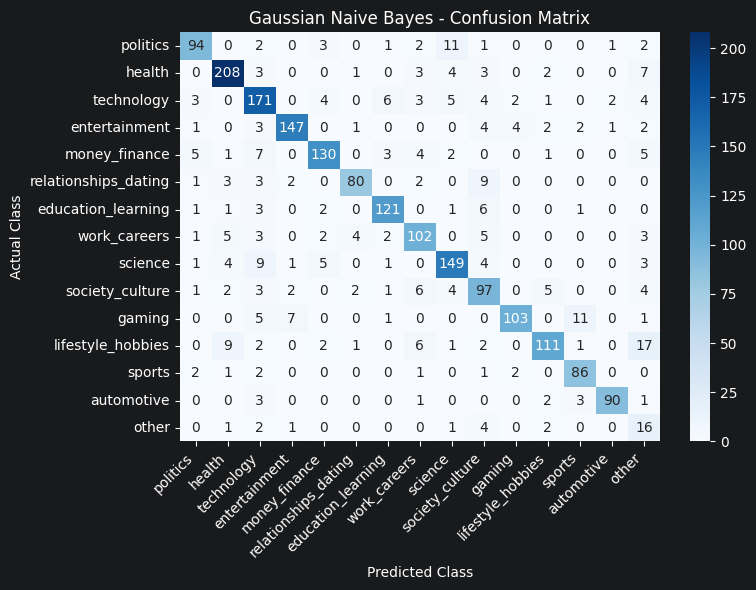


MODEL: Logistic Regression (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8947,0.8718,0.8831,117.0000
health,0.8602,0.8788,0.8694,231.0000
technology,0.8000,0.8390,0.8190,205.0000
entertainment,0.9048,0.9102,0.9075,167.0000
money_finance,0.9216,0.8924,0.9068,158.0000
relationships_dating,0.8878,0.8700,0.8788,100.0000
education_learning,0.9097,0.9632,0.9357,136.0000
work_careers,0.8516,0.8583,0.8549,127.0000
science,0.8249,0.8249,0.8249,177.0000
society_culture,0.7778,0.7165,0.7459,127.0000




--- Confusion Matrix ---


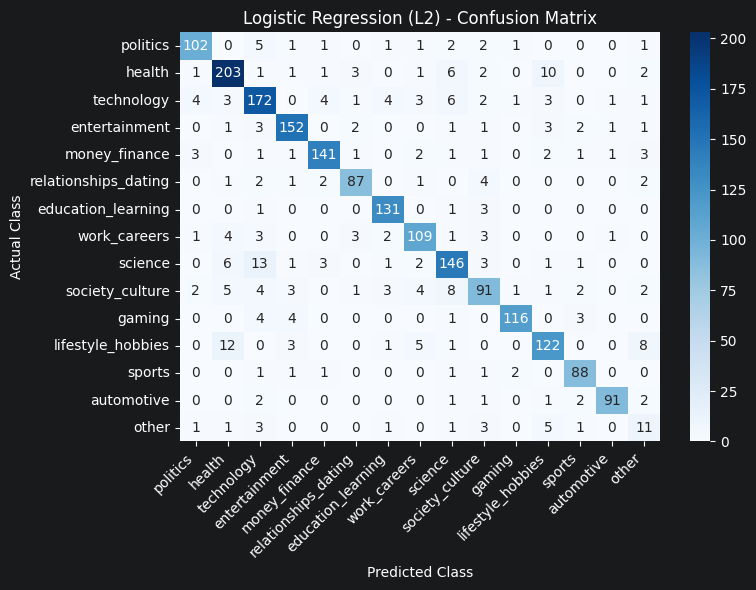


MODEL: Logistic Regression (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9052,0.8974,0.9013,117.000
health,0.8884,0.8961,0.8922,231.000
technology,0.8018,0.8488,0.8246,205.000
entertainment,0.9255,0.8922,0.9085,167.000
money_finance,0.9351,0.9114,0.9231,158.000
relationships_dating,0.9000,0.9000,0.9000,100.000
education_learning,0.9091,0.9559,0.9319,136.000
work_careers,0.8712,0.9055,0.8880,127.000
science,0.8400,0.8305,0.8352,177.000
society_culture,0.8053,0.7165,0.7583,127.000




--- Confusion Matrix ---


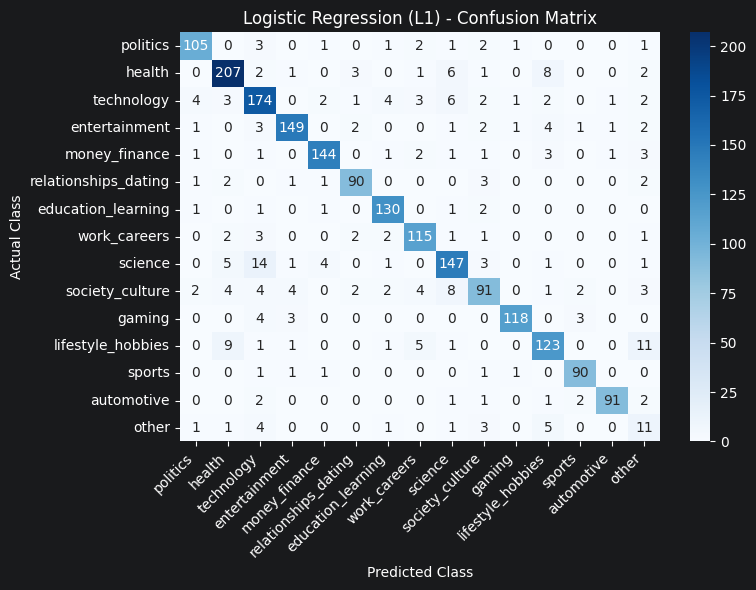


MODEL: Linear SVM (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8621,0.8547,0.8584,117.0000
health,0.9071,0.8874,0.8972,231.0000
technology,0.7647,0.8244,0.7934,205.0000
entertainment,0.9062,0.8683,0.8869,167.0000
money_finance,0.9051,0.9051,0.9051,158.0000
relationships_dating,0.8812,0.8900,0.8856,100.0000
education_learning,0.9155,0.9559,0.9353,136.0000
work_careers,0.8710,0.8504,0.8606,127.0000
science,0.7978,0.8023,0.8000,177.0000
society_culture,0.7632,0.6850,0.7220,127.0000




--- Confusion Matrix ---


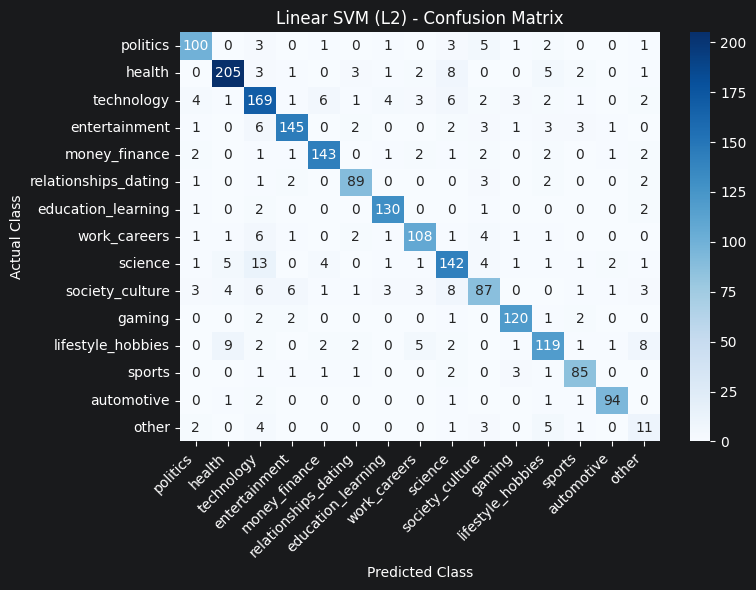


MODEL: Linear SVM (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8696,0.8547,0.8621,117.0000
health,0.8961,0.8961,0.8961,231.0000
technology,0.7706,0.8195,0.7943,205.0000
entertainment,0.9024,0.8862,0.8943,167.0000
money_finance,0.9236,0.9177,0.9206,158.0000
relationships_dating,0.8878,0.8700,0.8788,100.0000
education_learning,0.9149,0.9485,0.9314,136.0000
work_careers,0.8372,0.8504,0.8438,127.0000
science,0.7923,0.8192,0.8056,177.0000
society_culture,0.8073,0.6929,0.7458,127.0000




--- Confusion Matrix ---


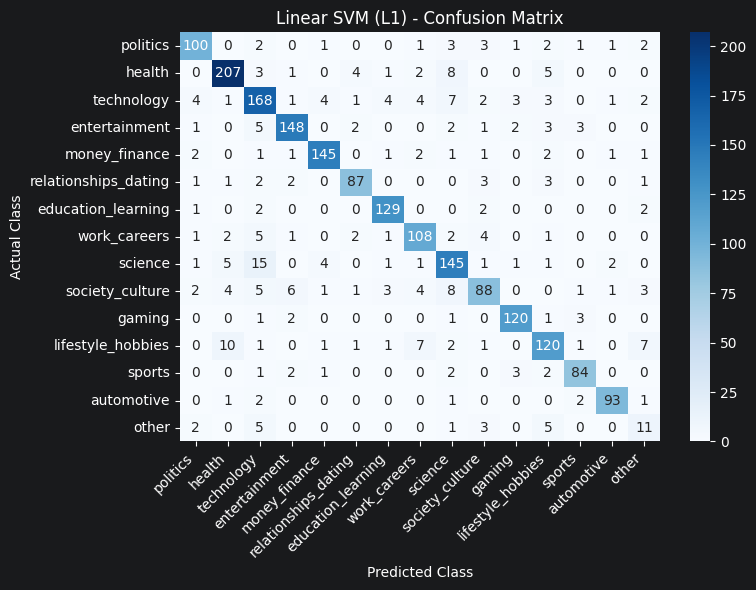


MODEL: Random Forest

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8783,0.8632,0.8707,117.0000
health,0.8378,0.9394,0.8857,231.0000
technology,0.7597,0.8634,0.8082,205.0000
entertainment,0.8728,0.9042,0.8882,167.0000
money_finance,0.9032,0.8861,0.8946,158.0000
relationships_dating,0.9545,0.8400,0.8936,100.0000
education_learning,0.8929,0.9191,0.9058,136.0000
work_careers,0.8538,0.8740,0.8638,127.0000
science,0.8177,0.8870,0.8509,177.0000
society_culture,0.8108,0.7087,0.7563,127.0000




--- Confusion Matrix ---


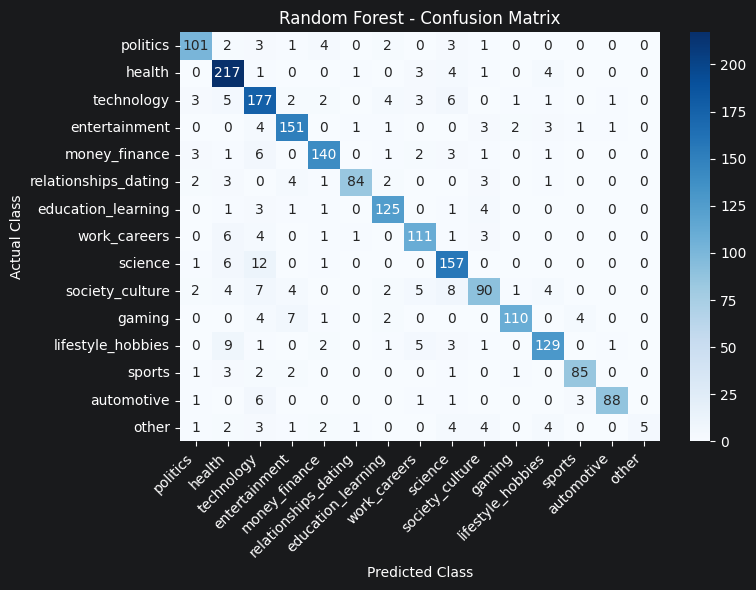


MODEL: XGBoost

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8644,0.8718,0.8681,117.0000
health,0.8760,0.9177,0.8964,231.0000
technology,0.7797,0.8634,0.8194,205.0000
entertainment,0.8941,0.9102,0.9021,167.0000
money_finance,0.9097,0.8924,0.9010,158.0000
relationships_dating,0.9053,0.8600,0.8821,100.0000
education_learning,0.9007,0.9338,0.9170,136.0000
work_careers,0.8605,0.8740,0.8672,127.0000
science,0.8500,0.8644,0.8571,177.0000
society_culture,0.7797,0.7244,0.7510,127.0000




--- Confusion Matrix ---


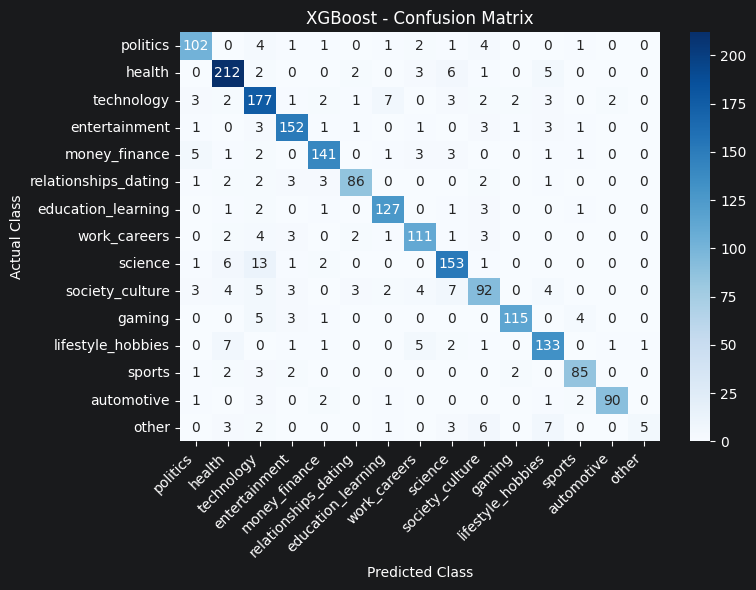

In [49]:
display_model_evaluations(confusion_matrices_embeddings_mean, class_reports_embeddings_mean, topics)

### Embeddings Max

In [50]:
metrics_df_embeddings_max, confusion_matrices_embeddings_max, class_reports_embeddings_max = evaluate_models(
    X_train_embeddings_max_final, X_test_embeddings_max_final, y_train_embeddings_max, y_test_embeddings_max, target_names=topics,is_embeddings=True
)

/home/joao-proenca/Desktop/MIA 1º Ano/2º Semestre/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [51]:
display(metrics_df_embeddings_max.sort_values(by='F1 (macro)', ascending=False))

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (weighted)
Model,,,,,,
XGBoost,0.875916,0.875389,0.875916,0.873472,0.848091,0.990724
Logistic Regression (L1),0.842697,0.847264,0.842697,0.844444,0.812395,0.986568
Random Forest,0.856375,0.852521,0.856375,0.851898,0.812270,0.983854
Gaussian Naive Bayes,0.812408,0.825512,0.812408,0.816148,0.792313,0.979613
Linear SVM (L1),0.815340,0.822527,0.815340,0.818028,0.785822,0.976417
Logistic Regression (L2),0.806058,0.811792,0.806058,0.808347,0.779453,0.981336
Linear SVM (L2),0.807035,0.813301,0.807035,0.809495,0.775051,0.975791



MODEL: Gaussian Naive Bayes

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8900,0.7607,0.8203,117.0000
health,0.8707,0.8745,0.8726,231.0000
technology,0.7565,0.8488,0.8000,205.0000
entertainment,0.8218,0.8563,0.8387,167.0000
money_finance,0.8986,0.8418,0.8693,158.0000
relationships_dating,0.8542,0.8200,0.8367,100.0000
education_learning,0.8309,0.8309,0.8309,136.0000
work_careers,0.7692,0.7874,0.7782,127.0000
science,0.7435,0.8023,0.7717,177.0000
society_culture,0.7143,0.7480,0.7308,127.0000




--- Confusion Matrix ---


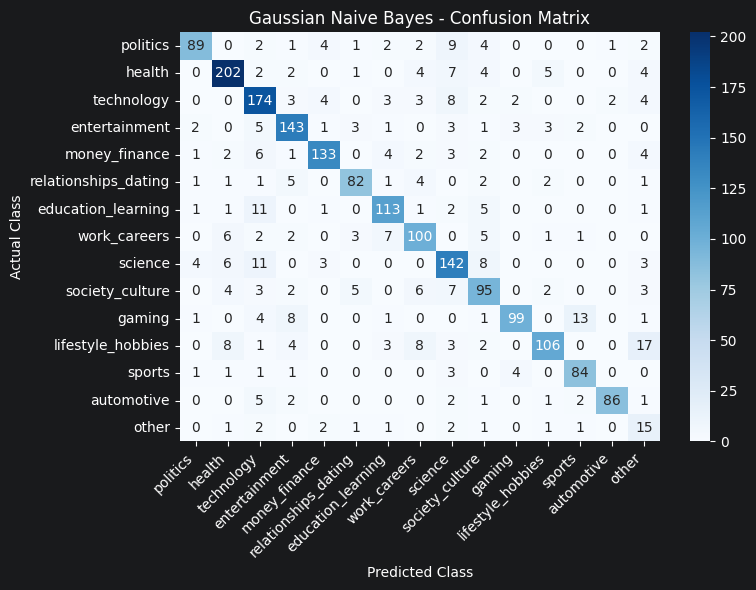


MODEL: Logistic Regression (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8000,0.7863,0.7931,117.0000
health,0.8276,0.8312,0.8294,231.0000
technology,0.7882,0.7805,0.7843,205.0000
entertainment,0.8662,0.8144,0.8395,167.0000
money_finance,0.8616,0.8671,0.8644,158.0000
relationships_dating,0.8105,0.7700,0.7897,100.0000
education_learning,0.8531,0.8971,0.8746,136.0000
work_careers,0.7698,0.8425,0.8045,127.0000
science,0.8059,0.7740,0.7896,177.0000
society_culture,0.6992,0.6772,0.6880,127.0000




--- Confusion Matrix ---


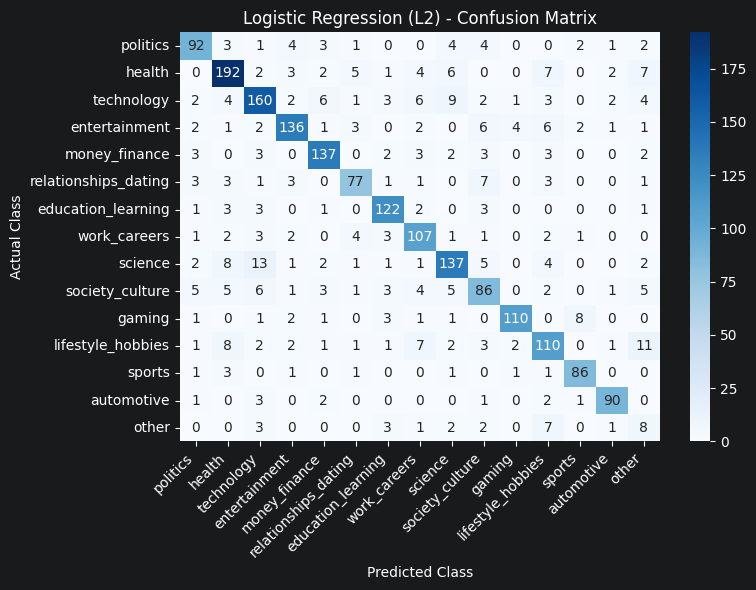


MODEL: Logistic Regression (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8750,0.8376,0.8559,117.0000
health,0.8739,0.9004,0.8870,231.0000
technology,0.7971,0.8049,0.8010,205.0000
entertainment,0.9000,0.8623,0.8807,167.0000
money_finance,0.9267,0.8797,0.9026,158.0000
relationships_dating,0.8673,0.8500,0.8586,100.0000
education_learning,0.8857,0.9118,0.8986,136.0000
work_careers,0.8015,0.8583,0.8289,127.0000
science,0.8371,0.8418,0.8394,177.0000
society_culture,0.7583,0.7165,0.7368,127.0000




--- Confusion Matrix ---


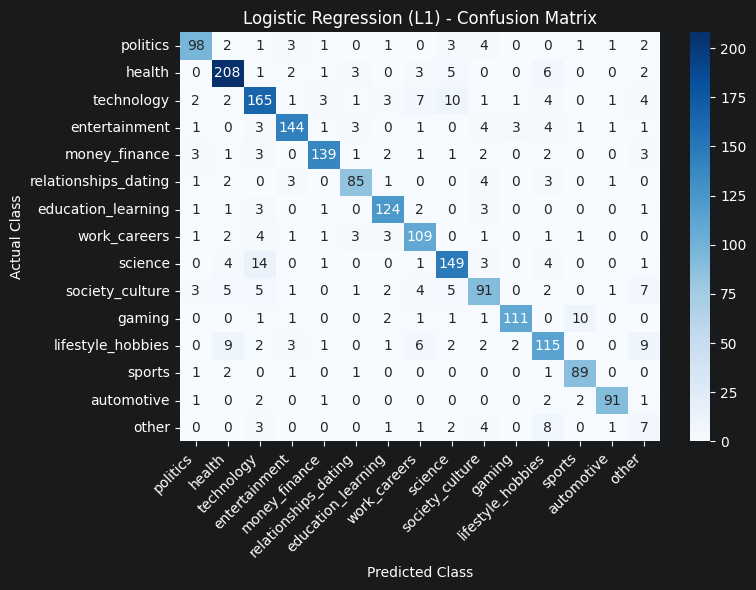


MODEL: Linear SVM (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8158,0.7949,0.8052,117.000
health,0.8333,0.8658,0.8493,231.000
technology,0.7570,0.7902,0.7733,205.000
entertainment,0.8375,0.8024,0.8196,167.000
money_finance,0.9041,0.8354,0.8684,158.000
relationships_dating,0.7624,0.7700,0.7662,100.000
education_learning,0.8355,0.9338,0.8819,136.000
work_careers,0.8400,0.8268,0.8333,127.000
science,0.8391,0.8249,0.8319,177.000
society_culture,0.6721,0.6457,0.6586,127.000




--- Confusion Matrix ---


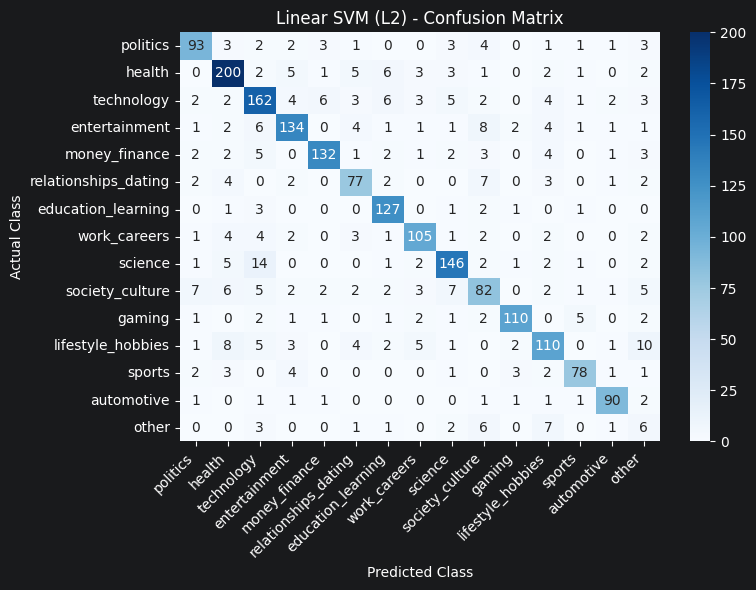


MODEL: Linear SVM (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8532,0.7949,0.8230,117.0000
health,0.8367,0.8874,0.8613,231.0000
technology,0.7477,0.7951,0.7707,205.0000
entertainment,0.8471,0.7964,0.8210,167.0000
money_finance,0.9172,0.8418,0.8779,158.0000
relationships_dating,0.7835,0.7600,0.7716,100.0000
education_learning,0.8523,0.9338,0.8912,136.0000
work_careers,0.8346,0.8346,0.8346,127.0000
science,0.8400,0.8305,0.8352,177.0000
society_culture,0.6562,0.6614,0.6588,127.0000




--- Confusion Matrix ---


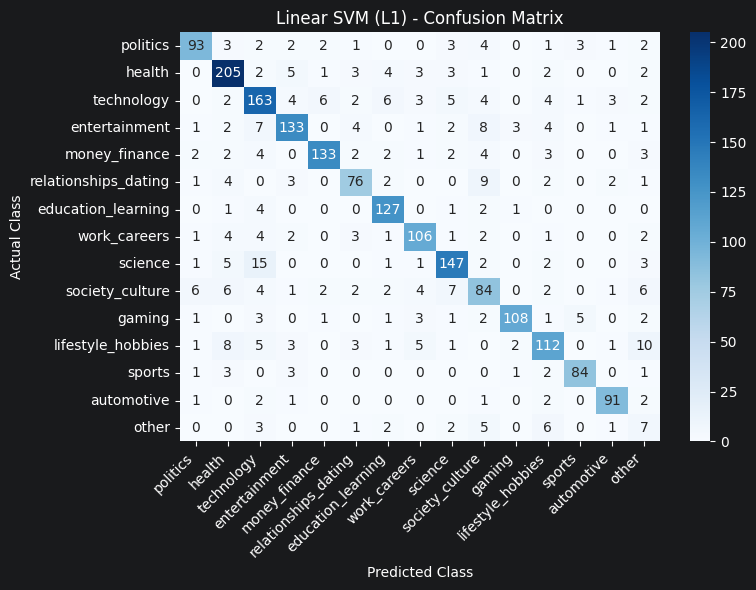


MODEL: Random Forest

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9592,0.8034,0.8744,117.0000
health,0.8192,0.9221,0.8676,231.0000
technology,0.7811,0.8878,0.8311,205.0000
entertainment,0.8427,0.8982,0.8696,167.0000
money_finance,0.8968,0.8797,0.8882,158.0000
relationships_dating,0.8958,0.8600,0.8776,100.0000
education_learning,0.8841,0.8971,0.8905,136.0000
work_careers,0.8321,0.8583,0.8450,127.0000
science,0.8370,0.8701,0.8532,177.0000
society_culture,0.8252,0.6693,0.7391,127.0000




--- Confusion Matrix ---


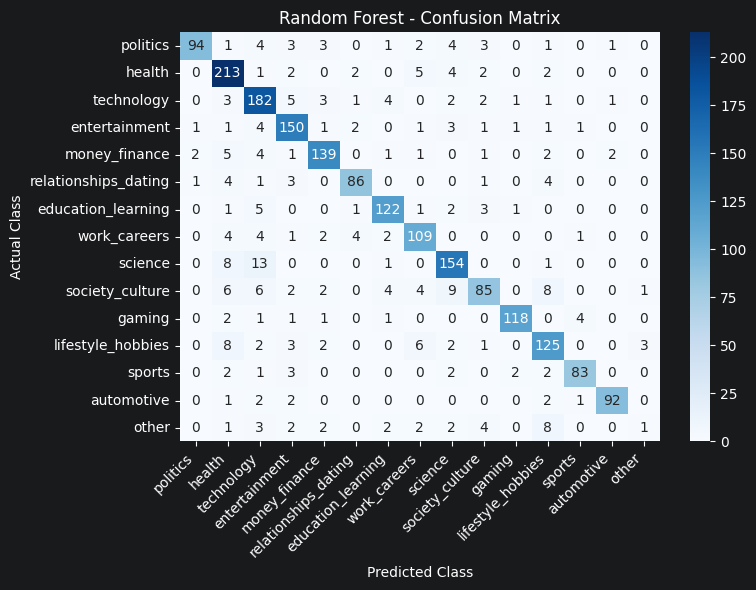


MODEL: XGBoost

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9065,0.8291,0.8661,117.0000
health,0.8531,0.9048,0.8782,231.0000
technology,0.7860,0.8780,0.8295,205.0000
entertainment,0.9024,0.8862,0.8943,167.0000
money_finance,0.9000,0.9114,0.9057,158.0000
relationships_dating,0.9175,0.8900,0.9036,100.0000
education_learning,0.9338,0.9338,0.9338,136.0000
work_careers,0.8519,0.9055,0.8779,127.0000
science,0.8508,0.8701,0.8603,177.0000
society_culture,0.8304,0.7323,0.7782,127.0000




--- Confusion Matrix ---


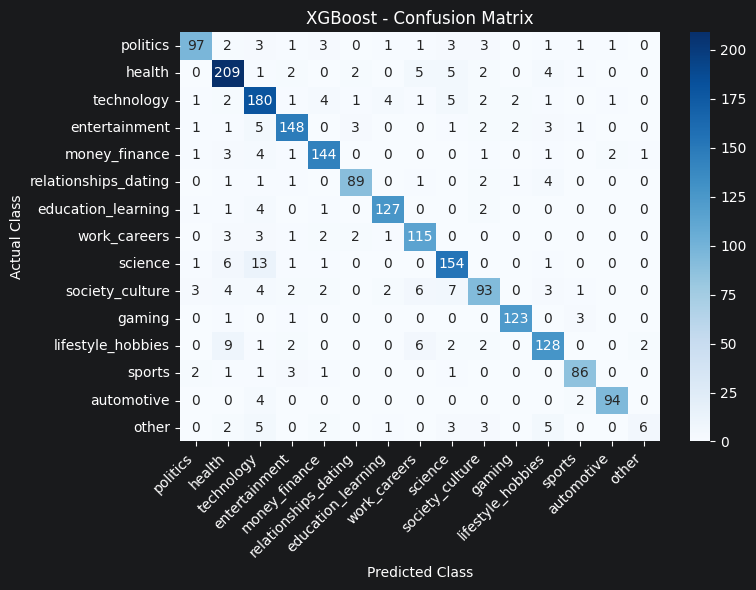

In [52]:
display_model_evaluations(confusion_matrices_embeddings_max, class_reports_embeddings_max, topics)

## Model Comparison

To compare the different approaches more clearly, we summarize the main evaluation metrics in a single table.

This makes it easier to identify whether TF-IDF improves over Bag-of-Words, and whether Logistic Regression or Linear SVM outperform the Naive Bayes baseline.

In [53]:
metrics_df_onehot.index = metrics_df_onehot.index.astype(str) + ' (One-Hot)'
metrics_df_tfidf.index = metrics_df_tfidf.index.astype(str) + ' (TF-IDF)'
metrics_df_bow.index = metrics_df_bow.index.astype(str) + ' (BoW)'
metrics_df_grams.index = metrics_df_grams.index.astype(str) + ' (grams)'
metrics_df_embeddings_mean.index = metrics_df_embeddings_mean.index.astype(str) + ' (embeddings mean)'
metrics_df_embeddings_max.index = metrics_df_embeddings_max.index.astype(str) + ' (embeddings max)'

In [54]:
all_metrics = pd.concat([
    metrics_df_onehot,
    metrics_df_tfidf,
    metrics_df_bow,
    metrics_df_grams,
    metrics_df_embeddings_mean,
    metrics_df_embeddings_max
])

all_metrics_sorted = all_metrics.sort_values(by='F1 (weighted)', ascending=False)

display(all_metrics_sorted.head(10))

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (weighted)
Model,,,,,,
Linear SVM (L1) (TF-IDF),0.900342,0.899409,0.900342,0.899215,0.875183,0.990173
Linear SVM (L2) (TF-IDF),0.898876,0.897270,0.898876,0.897429,0.869966,0.990517
Logistic Regression (L2) (grams),0.896434,0.895128,0.896434,0.895207,0.867157,0.993536
Linear SVM (L2) (grams),0.897899,0.895067,0.897899,0.895098,0.863967,0.989330
Logistic Regression (L2) (TF-IDF),0.891060,0.895602,0.891060,0.892651,0.866527,0.993248
Logistic Regression (L2) (One-Hot),0.892037,0.893029,0.892037,0.892110,0.863403,0.992517
Logistic Regression (L1) (One-Hot),0.889595,0.891170,0.889595,0.889802,0.867586,0.990825
Logistic Regression (L1) (grams),0.890083,0.889979,0.890083,0.889767,0.866255,0.992058
Logistic Regression (L2) (BoW),0.888129,0.890148,0.888129,0.888695,0.858869,0.992632


## Hyperparameter Tuning: Grid Search

In [55]:
top_meta_models_config = {
    'Linear SVM (L1) - TF-IDF + Meta': {
        'model': LinearSVC(penalty='l1', dual=False, max_iter=5000, class_weight='balanced', random_state=42),
        'X_train': X_train_tfidf_final,
        'y_train': y_train_tfidf,
        'param_grid': {
            'C': [0.01, 0.1, 1.0, 10.0],
            'tol': [1e-4, 1e-3]
        }
    },

    'Linear SVM (L2) - TF-IDF + Meta': {
        'model': LinearSVC(penalty='l2', max_iter=5000, class_weight='balanced', random_state=42),
        'X_train': X_train_tfidf_final,
        'y_train': y_train_tfidf,
        'param_grid': {
            'C': [0.01, 0.1, 1.0, 10.0],
            'loss': ['hinge', 'squared_hinge'],
            'tol': [1e-4, 1e-3]
        }
    },

    'Logistic Regression (L2) - N-grams + Meta': {
        'model': LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42, solver='lbfgs'),
        'X_train': X_train_grams_final,
        'y_train': y_train_tfidf,
        'param_grid': {
            'C': [0.01, 0.1, 1.0, 10.0],
            'tol': [1e-4, 1e-3]
        }
    }
}

In [56]:
best_meta_estimators = {}
meta_grid_results = []

print("Starting Grid Search for Meta-Feature Models... \n")

for name, config in top_meta_models_config.items():
    print(f"Tuning {name}...")

    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['param_grid'],
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1
    )

    # Fit the grid search using the specific X_train for this configuration
    grid.fit(config['X_train'], config['y_train'])

    # Store the best estimator
    best_meta_estimators[name] = grid.best_estimator_

    # Extract Mean and Std Deviation
    best_idx = grid.best_index_
    mean_score = grid.cv_results_['mean_test_score'][best_idx]
    std_score = grid.cv_results_['std_test_score'][best_idx]

    # Save the results
    meta_grid_results.append({
        'Model Configuration': name,
        'F1 Score (5-fold CV)': f"{mean_score:.4f} ﷿﷿ {std_score:.4f}",
        'Best Parameters': grid.best_params_
    })

    print(f"Done! Best Params: {grid.best_params_}\n")

Starting Grid Search for Meta-Feature Models... 

Tuning Linear SVM (L1) - TF-IDF + Meta...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


/home/joao-proenca/Desktop/MIA 1º Ano/2º Semestre/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/joao-proenca/Desktop/MIA 1º Ano/2º Semestre/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/joao-proenca/Desktop/MIA 1º Ano/2º Semestre/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/joao-proenca/Desktop/MIA 1º Ano/2º Semestre/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/joao-proenca/Desktop/MIA 1º Ano/2º Semestre/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear fa

Done! Best Params: {'C': 1.0, 'tol': 0.0001}

Tuning Linear SVM (L2) - TF-IDF + Meta...
Fitting 5 folds for each of 16 candidates, totalling 80 fits


/home/joao-proenca/Desktop/MIA 1º Ano/2º Semestre/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/joao-proenca/Desktop/MIA 1º Ano/2º Semestre/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/joao-proenca/Desktop/MIA 1º Ano/2º Semestre/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/joao-proenca/Desktop/MIA 1º Ano/2º Semestre/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/joao-proenca/Desktop/MIA 1º Ano/2º Semestre/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear fa

Done! Best Params: {'C': 1.0, 'loss': 'squared_hinge', 'tol': 0.001}

Tuning Logistic Regression (L2) - N-grams + Meta...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Done! Best Params: {'C': 1.0, 'tol': 0.0001}



In [57]:
pd.set_option('display.max_colwidth', None)
meta_results_df = pd.DataFrame(meta_grid_results).sort_values(by='F1 Score (5-fold CV)', ascending=False)
display(meta_results_df)

,Model Configuration,F1 Score (5-fold CV),Best Parameters
1,Linear SVM (L2) - TF-IDF + Meta,0.8935 ﷿﷿ 0.0048,"{'C': 1.0, 'loss': 'squared_hinge', 'tol': 0.001}"
2,Logistic Regression (L2) - N-grams + Meta,0.8883 ﷿﷿ 0.0037,"{'C': 1.0, 'tol': 0.0001}"
0,Linear SVM (L1) - TF-IDF + Meta,0.8862 ﷿﷿ 0.0030,"{'C': 1.0, 'tol': 0.0001}"


In [58]:
final_metrics_data = []
model_results = {}

print("--- FINAL TEST SET SCORES (Grid Search Winners) ---\n")

for model_name, tuned_model in best_meta_estimators.items():

    if "N-grams" in model_name:
        X_test_current = X_test_grams_final
        y_test_current = y_test_grams
    elif "TF-IDF" in model_name:
        X_test_current = X_test_tfidf_final
        y_test_current = y_test_tfidf
    else:
        print(f"Skipping unknown feature set for {model_name}")
        continue

    y_pred = tuned_model.predict(X_test_current)

    if hasattr(tuned_model, "predict_proba"):
        y_scores_prob = tuned_model.predict_proba(X_test_current)
    else:
        y_scores_raw = tuned_model.decision_function(X_test_current)
        y_scores_prob = softmax(y_scores_raw, axis=1)

    acc = accuracy_score(y_test_current, y_pred)
    prec = precision_score(y_test_current, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_current, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_current, y_pred, average='weighted', zero_division=0)
    roc_auc = roc_auc_score(y_test_current, y_scores_prob, multi_class='ovr', average='weighted')

    final_metrics_data.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision (Weighted)': prec,
        'Recall (Weighted)': rec,
        'F1 Score (Weighted)': f1,
        'ROC-AUC (Weighted)': roc_auc
    })

    model_results[model_name] = {
        'y_test': y_test_current,
        'y_pred': y_pred
    }

final_metrics_df = pd.DataFrame(final_metrics_data).set_index('Model')
sorted_metrics_df = final_metrics_df.sort_values(by='F1 Score (Weighted)', ascending=False)

display(sorted_metrics_df)

--- FINAL TEST SET SCORES (Grid Search Winners) ---



,Accuracy,Precision (Weighted),Recall (Weighted),F1 Score (Weighted),ROC-AUC (Weighted)
Model,,,,,
Linear SVM (L1) - TF-IDF + Meta,0.900342,0.899409,0.900342,0.899215,0.990173
Linear SVM (L2) - TF-IDF + Meta,0.898876,0.897117,0.898876,0.897331,0.990533
Logistic Regression (L2) - N-grams + Meta,0.896434,0.895128,0.896434,0.895207,0.993536


In [59]:
best_model_name = sorted_metrics_df.index[0]

print(f"\n{'='*70}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*70}\n")

best_y_test = model_results[best_model_name]['y_test']
best_y_pred = model_results[best_model_name]['y_pred']


BEST MODEL: Linear SVM (L1) - TF-IDF + Meta



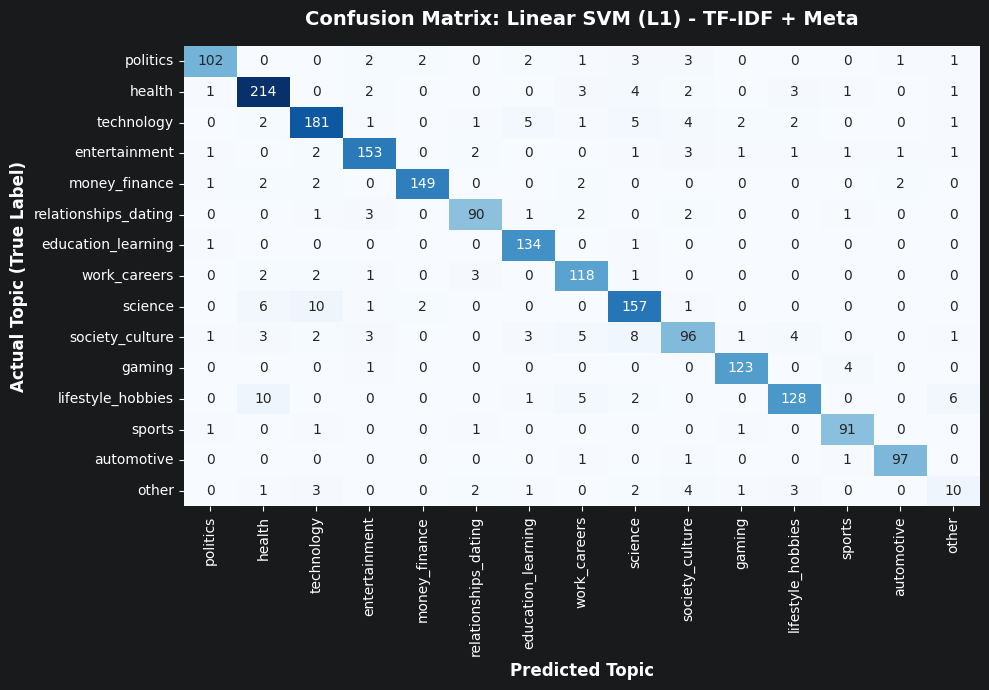

In [60]:
cm = confusion_matrix(best_y_test, best_y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=topics, yticklabels=topics)

plt.title(f'Confusion Matrix: {best_model_name}', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Topic (True Label)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Topic', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()



In [61]:
report_dict = classification_report(best_y_test, best_y_pred, target_names=topics, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()

print("Classification Report:")
display(report_df.round(4))

Classification Report:


,precision,recall,f1-score,support
politics,0.9444,0.8718,0.9067,117.0000
health,0.8917,0.9264,0.9087,231.0000
technology,0.8873,0.8829,0.8851,205.0000
entertainment,0.9162,0.9162,0.9162,167.0000
money_finance,0.9739,0.9430,0.9582,158.0000
relationships_dating,0.9091,0.9000,0.9045,100.0000
education_learning,0.9116,0.9853,0.9470,136.0000
work_careers,0.8551,0.9291,0.8906,127.0000
science,0.8533,0.8870,0.8698,177.0000
society_culture,0.8276,0.7559,0.7901,127.0000
